# Cell 0 — cuda details

In [3]:
print(cp.cuda.runtime.getDeviceCount(), "CUDA device(s)")
cp.show_config()


1 CUDA device(s)
OS                           : Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.35
Python Version               : 3.10.18
CuPy Version                 : 13.5.1
CuPy Platform                : NVIDIA CUDA
NumPy Version                : 2.2.6
SciPy Version                : 1.15.2
Cython Build Version         : 3.0.12
Cython Runtime Version       : None
CUDA Root                    : /usr/local/cuda
nvcc PATH                    : /usr/local/cuda/bin/nvcc
CUDA Build Version           : 12090
CUDA Driver Version          : 13000
CUDA Runtime Version         : 12090 (linked to CuPy) / 12090 (locally installed)
CUDA Extra Include Dirs      : ['/home/askiran/miniconda/envs/imaging-gpu/lib/python3.10/site-packages/nvidia/cuda_runtime/include']
cuBLAS Version               : (available)
cuFFT Version                : 11303
cuRAND Version               : 10309
cuSOLVER Version             : (11, 7, 3)
cuSPARSE Version             : (available)
NVRTC Version               

# Cell 1 — Imports & common helpers
Set up libraries, grayscale I/O, dtype round-trip, sorting, preview metrics, and a small display helper.


In [1]:
# ===== Imports =====
import os, re, math
import numpy as np, cupy as cp
import imageio.v3 as iio
import matplotlib.pyplot as plt
from glob import glob
from cupyx.scipy import ndimage as cnd            # GPU ndimage (CuPy)
from scipy import ndimage as ndi                  # CPU ndimage (for metrics/estimates)

try:
    from tqdm import tqdm
except Exception:
    def tqdm(x, **k): return x  # no-op fallback

# ===== Common helpers (grayscale IO + dtype round-trip + sorting) =====
def natural_key(s):  # "slice_2" < "slice_10"
    return [int(t) if t.isdigit() else t.lower() for t in re.findall(r'\d+|\D+', s)]

def list_files_gray(folder, exts=("*.tif","*.tiff","*.png","*.jpg","*.jpeg","*.bmp")):
    files = sum([glob(os.path.join(folder, e)) for e in exts], [])
    files = sorted(files, key=natural_key)
    assert files, f"No images in {folder}"
    return files

def read_slice_gray(path):
    im = iio.imread(path)
    if im.ndim == 3:  # RGB -> luminance
        im = (0.2126*im[...,0] + 0.7152*im[...,1] + 0.0722*im[...,2]).astype(im.dtype)
    return im

def to_float01(img):
    if img.dtype == np.uint8:  return img.astype(np.float32)/255.0,   {"dtype": np.uint8,  "scale": 255.0}
    if img.dtype == np.uint16: return img.astype(np.float32)/65535.0, {"dtype": np.uint16, "scale": 65535.0}
    if np.issubdtype(img.dtype, np.floating): return img.astype(np.float32), {"dtype": img.dtype, "scale": 1.0}
    return img.astype(np.float32), {"dtype": img.dtype, "scale": 1.0}

def from_float01(arr, meta):
    scale, odt = meta["scale"], meta["dtype"]
    if odt == np.uint8:  return (np.clip(arr,0,1)*scale + 0.5).astype(np.uint8)
    if odt == np.uint16: return (np.clip(arr,0,1)*scale + 0.5).astype(np.uint16)
    if np.issubdtype(odt, np.floating): return arr.astype(odt)
    return arr

def choose_middle_indices(n, k):
    k = min(k, n)
    mid = n//2
    start = max(0, mid - k//2)
    end = min(n, start + k)
    return list(range(start, end))

# ===== Simple, reference-free metrics (optional) =====
def estimate_sigma_mad3d(vol_f01):
    lap = ndi.laplace(vol_f01)
    mad = np.median(np.abs(lap - np.median(lap)))
    return float(mad / 0.6745)

def quality_metrics_3d(before_f01, after_f01, edge_q=0.85, alpha=0.6, beta=0.4):
    b = before_f01.astype(np.float32); a = after_f01.astype(np.float32)
    gx_b = ndi.sobel(b, axis=2); gy_b = ndi.sobel(b, axis=1); gz_b = ndi.sobel(b, axis=0)
    gx_a = ndi.sobel(a, axis=2); gy_a = ndi.sobel(a, axis=1); gz_a = ndi.sobel(a, axis=0)
    gb = np.sqrt(gx_b**2 + gy_b**2 + gz_b**2)
    ga = np.sqrt(gx_a**2 + gy_a**2 + gz_a**2)
    thr = np.quantile(gb, edge_q)
    edge = gb >= thr
    flat = gb <= np.quantile(gb, 0.5)
    var_b = float(np.var(b[flat])); var_a = float(np.var(a[flat]))
    noise_reduction = (var_b / max(var_a,1e-8)) if var_a>0 else np.inf
    ge_b = float(np.mean(gb[edge]**2)); ge_a = float(np.mean(ga[edge]**2))
    edge_retention = ge_a / max(ge_b,1e-8)
    score = alpha*noise_reduction + beta*edge_retention
    return dict(score=score, noise_reduction=noise_reduction, edge_retention=edge_retention,
                var_before=var_b, var_after=var_a)

def show_pair(a, b, title_a="Before", title_b="After", percentile=(1,99)):
    p_lo, p_hi = np.percentile(a, list(percentile))
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1); plt.imshow(a, cmap="gray", vmin=p_lo, vmax=p_hi); plt.title(title_a); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(b, cmap="gray", vmin=p_lo, vmax=p_hi); plt.title(title_b); plt.axis("off")
    plt.show()

# Cell 2.1 — Prereqs: 3D Median (choose input path & parameters)
Configure input folder and median kernel (size). Defines the GPU median function.


In [17]:
# ===== CONFIG: 3D MEDIAN =====
MED_DATA_DIR = "/home/askiran/data/Normalized_log"   # <-- change per dataset
MED_K_PREVIEW = 2                                      # ~10 middle slices
MED_SIZE = (20,15,15)                                      # kernel size (odd); anisotropic-friendly
MED_SLAB = 50                                          # core slices per pass for full run
OUT_MED_PREV = f"{MED_DATA_DIR.rstrip('/')}/_median3d_preview"
OUT_MED_FULL = f"{MED_DATA_DIR.rstrip('/')}/_median3d_full"

os.makedirs(OUT_MED_PREV, exist_ok=True)
os.makedirs(OUT_MED_FULL, exist_ok=True)

def ensure_odd_triplet(sz):
    if isinstance(sz, int): sz = (sz,sz,sz)
    return tuple(max(1, s|1) for s in sz)

def median3d_cupy(vol_f01, size=(3,3,3)):
    size = ensure_odd_triplet(size)
    x = cp.asarray(vol_f01, dtype=cp.float32)
    y = cnd.median_filter(x, size=size, mode='reflect')
    return cp.asnumpy(y)

# Cell 2.2 — 3D Median: preview on ~10 middle slices (tune size)
Runs median on a small stack; shows metrics & side-by-side visuals; optionally saves preview slices.


Median preview metrics: {'score': 1.059435383270571, 'noise_reduction': 1.7646944669660234, 'edge_retention': 0.001546757727392282, 'var_before': 0.003569666761904955, 'var_after': 0.002022824250161648}


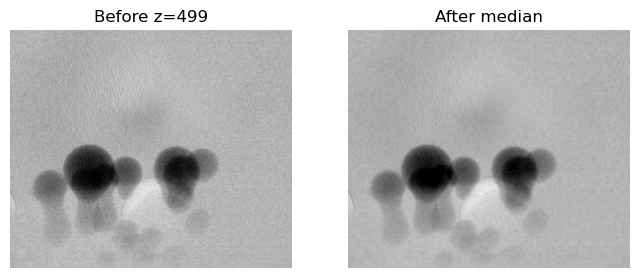

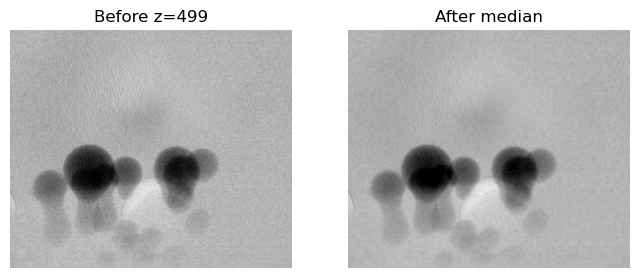

Use MED_SIZE to balance speckle removal vs detail. Try (3,3,3) for finer detail, (5,5,5) for heavier speckle.


In [18]:
files = list_files_gray(MED_DATA_DIR)
idxs = choose_middle_indices(len(files), MED_K_PREVIEW)

# Build preview block (float [0,1])
volK = np.stack([to_float01(read_slice_gray(files[k]))[0] for k in idxs], axis=0).astype(np.float32)

# Run median
denK = median3d_cupy(volK, size=MED_SIZE)

# Metrics + two-slice visuals
qm = quality_metrics_3d(volK, denK)
print("Median preview metrics:", qm)
for ii in [len(idxs)//2, min(len(idxs)//2+1, len(idxs)-1)]:
    show_pair(volK[ii], denK[ii], f"Before z={idxs[ii]}", "After median")

# Save preview (preserve dtype/size)
for i, z in enumerate(idxs):
    s = read_slice_gray(files[z])
    out_u = from_float01(denK[i], {"dtype": s.dtype, "scale": (255.0 if s.dtype==np.uint8 else 65535.0)})
    iio.imwrite(os.path.join(OUT_MED_PREV, f"slice_{z:04d}_median.tif"), out_u)

print("Use MED_SIZE to balance speckle removal vs detail. Try (3,3,3) for finer detail, (5,5,5) for heavier speckle.")


# Cell 2.3 — 3D Median: full dataset (Z-slab streaming)
Processes all slices with overlap; saves output per slice, preserving shape and bit-depth.


In [6]:
files = list_files_gray(MED_DATA_DIR)
hz = ensure_odd_triplet(MED_SIZE)[0] // 2  # Z overlap = half kernel in Z

for z0 in tqdm(range(0, len(files), MED_SLAB), desc="Median3D full"):
    z1 = min(z0 + MED_SLAB, len(files))
    zs = max(0, z0 - hz); ze = min(len(files), z1 + hz)

    slab = np.stack([to_float01(read_slice_gray(p))[0] for p in files[zs:ze]], axis=0).astype(np.float32)
    den_ext = median3d_cupy(slab, size=MED_SIZE)
    core = den_ext[(z0 - zs):(z1 - zs)]

    for i, z in enumerate(range(z0, z1)):
        s = read_slice_gray(files[z])
        out_u = from_float01(core[i], {"dtype": s.dtype, "scale": (255.0 if s.dtype==np.uint8 else 65535.0)})
        iio.imwrite(os.path.join(OUT_MED_FULL, f"slice_{z:04d}.tif"), out_u)

print("Median full output:", OUT_MED_FULL)


Median3D full: 100%|█████████████████████████████████████████████████████████████████████████████████| 20/20 [04:38<00:00, 13.90s/it]

Median full output: /home/askiran/data/Normalized_log/_median3d_full


# Cell 3.1 — Prereqs: 3D NLM (choose input path & parameters)
Configure input, patch/search radii, H_FACTOR. Defines the GPU NLM function.


In [23]:
# ===== CONFIG: 3D NLM =====
NLM_DATA_DIR = "/home/askiran/data/Normalized_log"   # <-- change per dataset
NLM_K_PREVIEW = 2
PATCH_RADIUS  = (5,5,5)     # (rz,ry,rx)
SEARCH_RADIUS = (12,12,12)     # main runtime driver
H_FACTOR      = 0.8         # h = H_FACTOR * sigma
NLM_SLAB      = 20
OUT_NLM_PREV  = f"{NLM_DATA_DIR.rstrip('/')}/_nlm3d_preview"
OUT_NLM_FULL  = f"{NLM_DATA_DIR.rstrip('/')}/_nlm3d_full"

os.makedirs(OUT_NLM_PREV, exist_ok=True)
os.makedirs(OUT_NLM_FULL, exist_ok=True)

def nlm_cupy_3d(vol_f01, patch_radius=(1,1,1), search_radius=(2,6,6), h=0.8, sigma=None, use_box=True):
    x = cp.asarray(vol_f01, dtype=cp.float32)
    def triple(v): return (v,v,v) if isinstance(v, int) else v
    pr = tuple(int(p) for p in triple(patch_radius))
    sr = tuple(int(s) for s in triple(search_radius))
    k  = (2*pr[0]+1, 2*pr[1]+1, 2*pr[2]+1)
    patch_size = k[0]*k[1]*k[2]

    def agg(arr):
        if use_box:
            return cnd.uniform_filter(arr, size=k, mode='reflect') * patch_size
        else:
            sig = tuple(max(1.0, p*0.5) for p in pr)
            return cnd.gaussian_filter(arr, sigma=sig, mode='reflect')

    acc_num = cp.zeros_like(x); acc_den = cp.zeros_like(x)
    for dz in range(-sr[0], sr[0]+1):
        for dy in range(-sr[1], sr[1]+1):
            for dx in range(-sr[2], sr[2]+1):
                y = cp.roll(x, (dz,dy,dx), axis=(0,1,2))
                diff2 = (x - y)**2
                ssd = agg(diff2)
                if sigma is not None:
                    ssd = cp.maximum(ssd - 2.0*(sigma**2)*patch_size, 0.0)
                w = cp.exp(-ssd/(h*h))
                acc_num += w * y
                acc_den += w
    out = acc_num / cp.maximum(acc_den, cp.finfo(cp.float32).eps)
    return cp.asnumpy(out)


# Cell 3.2 — 3D NLM: preview on ~10 middle slices (tune params)
Estimates noise σ, runs NLM on a small stack, reports metrics & visuals; saves preview slices.


NLM preview metrics: {'score': 1.0700474762686003, 'noise_reduction': 1.7831978899750436, 'edge_retention': 0.0003218557089355863, 'var_before': 0.003569666761904955, 'var_after': 0.002001834334805608}


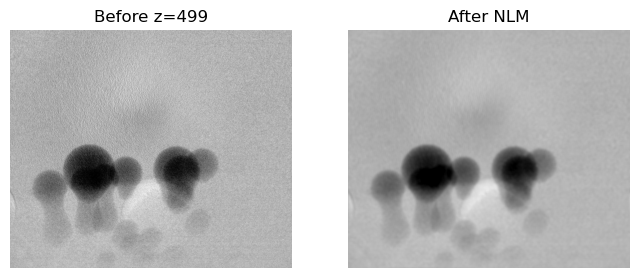

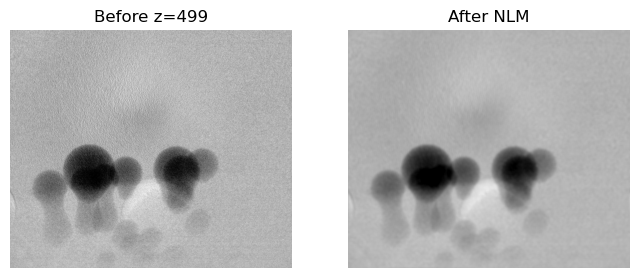

Tune PATCH_RADIUS/SEARCH_RADIUS/H_FACTOR here. Lower H_FACTOR for sharper edges; raise for more denoise.


In [24]:
files = list_files_gray(NLM_DATA_DIR)
idxs = choose_middle_indices(len(files), NLM_K_PREVIEW)

volK = np.stack([to_float01(read_slice_gray(files[k]))[0] for k in idxs], axis=0).astype(np.float32)
sigma_est = estimate_sigma_mad3d(volK)
h = float(H_FACTOR * sigma_est)

denK = nlm_cupy_3d(volK, patch_radius=PATCH_RADIUS, search_radius=SEARCH_RADIUS, h=h, sigma=sigma_est, use_box=True)

qm = quality_metrics_3d(volK, denK)
print("NLM preview metrics:", qm)
for ii in [len(idxs)//2, min(len(idxs)//2+1, len(idxs)-1)]:
    show_pair(volK[ii], denK[ii], f"Before z={idxs[ii]}", "After NLM")

for i, z in enumerate(idxs):
    s = read_slice_gray(files[z])
    out_u = from_float01(denK[i], {"dtype": s.dtype, "scale": (255.0 if s.dtype==np.uint8 else 65535.0)})
    iio.imwrite(os.path.join(OUT_NLM_PREV, f"slice_{z:04d}_nlm.tif"), out_u)

print("Tune PATCH_RADIUS/SEARCH_RADIUS/H_FACTOR here. Lower H_FACTOR for sharper edges; raise for more denoise.")


# Cell 3.3 — 3D NLM: full dataset (Z-slab streaming)
Uses fixed h (= H_FACTOR·σ_typ) or switch to adaptive per slab; saves output per slice.


In [9]:
files = list_files_gray(NLM_DATA_DIR)
pr = PATCH_RADIUS if isinstance(PATCH_RADIUS, tuple) else (PATCH_RADIUS,)*3
sr = SEARCH_RADIUS if isinstance(SEARCH_RADIUS, tuple) else (SEARCH_RADIUS,)*3
ovl_z = pr[0] + sr[0]

# Typical sigma from small central slab for fixed h (fast & stable)
mid = len(files)//2
probe = np.stack([to_float01(read_slice_gray(files[k]))[0] for k in range(max(0,mid-5), min(len(files), mid+5))], axis=0).astype(np.float32)
sigma_typ = estimate_sigma_mad3d(probe); del probe
h_fixed = float(H_FACTOR * sigma_typ)
print(f"Using fixed h={h_fixed:.6f} (H_FACTOR={H_FACTOR:.2f}, sigma≈{sigma_typ:.6f})")

for z0 in tqdm(range(0, len(files), NLM_SLAB), desc="NLM3D full"):
    z1 = min(z0 + NLM_SLAB, len(files))
    zs = max(0, z0 - ovl_z); ze = min(len(files), z1 + ovl_z)

    slab = np.stack([to_float01(read_slice_gray(p))[0] for p in files[zs:ze]], axis=0).astype(np.float32)
    den_ext = nlm_cupy_3d(slab, patch_radius=PATCH_RADIUS, search_radius=SEARCH_RADIUS, h=h_fixed, sigma=None, use_box=True)
    core = den_ext[(z0 - zs):(z1 - zs)]

    for i, z in enumerate(range(z0, z1)):
        s = read_slice_gray(files[z])
        out_u = from_float01(core[i], {"dtype": s.dtype, "scale": (255.0 if s.dtype==np.uint8 else 65535.0)})
        iio.imwrite(os.path.join(OUT_NLM_FULL, f"slice_{z:04d}.tif"), out_u)

print("NLM full output:", OUT_NLM_FULL)


Using fixed h=0.000769 (H_FACTOR=0.50, sigma≈0.001538)


NLM3D full: 100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [1:16:46<00:00, 92.13s/it]

NLM full output: /home/askiran/data/Normalized_log/_median3d_full/_nlm3d_full


# Cell 4.1 — Prereqs: 3D Anisotropic Diffusion (choose input path & parameters)
Configure iterations, conductance (k), step (λ), voxel spacing; defines GPU Perona–Malik.


In [8]:
# ===== CONFIG: 3D ANISOTROPIC DIFFUSION =====
AD_DATA_DIR = "/home/askiran/data/Normalized_log"   # <-- change per dataset
AD_K_PREVIEW = 2
AD_ITERS   = 200           # number of iterations
AD_K       = 0.05         # conductance (in [0,1] units after normalization); smaller preserves edges more
AD_LAMBDA  = 0.1         # time step; keep <= 0.25 for stability with 6-neighbors
AD_FUNC    = "exp"        # "exp" or "lorentz" (1/(1+(g/k)^2))
VOX_SPACING = (1.0, 1.0, 1.0)  # (dz, dy, dx) voxel size; set dz>1 if slices are thicker
AD_SLAB    = 50
OUT_AD_PREV = f"{AD_DATA_DIR.rstrip('/')}/_adiff3d_preview"
OUT_AD_FULL = f"{AD_DATA_DIR.rstrip('/')}/_adiff3d_full"

os.makedirs(OUT_AD_PREV, exist_ok=True)
os.makedirs(OUT_AD_FULL, exist_ok=True)

def adiff3d_cupy(vol_f01, iters=10, k=0.05, lam=0.15, func="exp", vox=(1.0,1.0,1.0)):
    """
    3D Perona–Malik (6-neighbor) on GPU.
    vol_f01: float32 (Z,Y,X) in [0,1]
    func: 'exp' => exp(-(g/k)^2); 'lorentz' => 1/(1+(g/k)^2)
    vox: (dz,dy,dx) used to scale gradients for anisotropic spacing.
    """
    x = cp.asarray(vol_f01, dtype=cp.float32)
    lam = float(min(lam, 0.25))  # safety
    dz, dy, dx = [cp.float32(v) for v in vox]
    wZ, wY, wX = 1.0/dz, 1.0/dy, 1.0/dx   # scale gradients by spacing

    for _ in range(int(iters)):
        N = cp.roll(x, -1, axis=0) - x   # forward diffs with wrap; 'reflect' via manual clamping is costly; wrap is fine w/ overlap tiling
        S = cp.roll(x,  1, axis=0) - x
        E = cp.roll(x, -1, axis=2) - x
        W = cp.roll(x,  1, axis=2) - x
        U = cp.roll(x, -1, axis=1) - x
        D = cp.roll(x,  1, axis=1) - x

        gN, gS = cp.abs(N)*wZ, cp.abs(S)*wZ
        gE, gW = cp.abs(E)*wX, cp.abs(W)*wX
        gU, gD = cp.abs(U)*wY, cp.abs(D)*wY

        if func == "lorentz":
            cN = 1.0 / (1.0 + (gN/k)**2); cS = 1.0 / (1.0 + (gS/k)**2)
            cE = 1.0 / (1.0 + (gE/k)**2); cW = 1.0 / (1.0 + (gW/k)**2)
            cU = 1.0 / (1.0 + (gU/k)**2); cD = 1.0 / (1.0 + (gD/k)**2)
        else:
            cN = cp.exp(-(gN/k)**2);      cS = cp.exp(-(gS/k)**2)
            cE = cp.exp(-(gE/k)**2);      cW = cp.exp(-(gW/k)**2)
            cU = cp.exp(-(gU/k)**2);      cD = cp.exp(-(gD/k)**2)

        flux = cN*N + cS*S + cE*E + cW*W + cU*U + cD*D
        x = cp.clip(x + lam*flux, 0.0, 1.0)
    return cp.asnumpy(x)


# Cell 4.2 — 3D Anisotropic Diffusion: preview on ~10 middle slices
Runs diffusion on a small stack; shows visuals; saves preview slices for inspection.


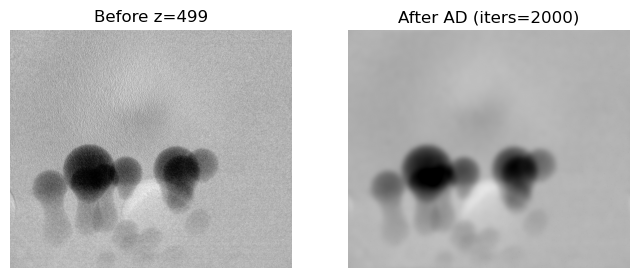

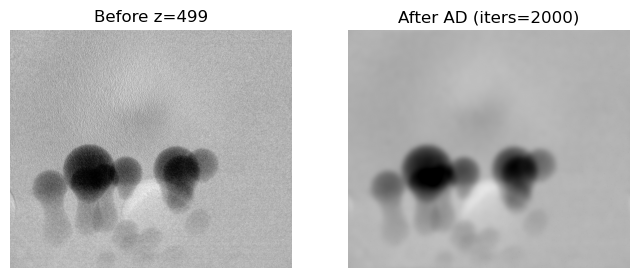

Tune AD_ITERS (more → smoother), AD_K (smaller → stronger edge-preservation), AD_LAMBDA (≤0.25).


In [9]:
files = list_files_gray(AD_DATA_DIR)
idxs = choose_middle_indices(len(files), AD_K_PREVIEW)

volK = np.stack([to_float01(read_slice_gray(files[k]))[0] for k in idxs], axis=0).astype(np.float32)
denK = adiff3d_cupy(volK, iters=AD_ITERS, k=AD_K, lam=AD_LAMBDA, func=AD_FUNC, vox=VOX_SPACING)

# Visuals + optional metrics (diffusion is edge-preserving; metrics may show mild edge_gain ~1)
for ii in [len(idxs)//2, min(len(idxs)//2+1, len(idxs)-1)]:
    show_pair(volK[ii], denK[ii], f"Before z={idxs[ii]}", f"After AD (iters={AD_ITERS})")

for i, z in enumerate(idxs):
    s = read_slice_gray(files[z])
    out_u = from_float01(denK[i], {"dtype": s.dtype, "scale": (255.0 if s.dtype==np.uint8 else 65535.0)})
    iio.imwrite(os.path.join(OUT_AD_PREV, f"slice_{z:04d}_adiff.tif"), out_u)

print("Tune AD_ITERS (more → smoother), AD_K (smaller → stronger edge-preservation), AD_LAMBDA (≤0.25).")


# Cell 4.3 — 3D Anisotropic Diffusion: full dataset (Z-slab streaming)
Runs diffusion across the full stack with safe Z-overlap; saves outputs per slice.


In [ ]:
files = list_files_gray(AD_DATA_DIR)

# Overlap in Z: ~ number of iterations (interaction grows ~1 voxel/iter). Cap to reasonable.
AD_OVL_Z = int(min(16, max(2, AD_ITERS)))  # conservative overlap

for z0 in tqdm(range(0, len(files), AD_SLAB), desc="ADiff3D full"):
    z1 = min(z0 + AD_SLAB, len(files))
    zs = max(0, z0 - AD_OVL_Z); ze = min(len(files), z1 + AD_OVL_Z)

    slab = np.stack([to_float01(read_slice_gray(p))[0] for p in files[zs:ze]], axis=0).astype(np.float32)
    den_ext = adiff3d_cupy(slab, iters=AD_ITERS, k=AD_K, lam=AD_LAMBDA, func=AD_FUNC, vox=VOX_SPACING)
    core = den_ext[(z0 - zs):(z1 - zs)]

    for i, z in enumerate(range(z0, z1)):
        s = read_slice_gray(files[z])
        out_u = from_float01(core[i], {"dtype": s.dtype, "scale": (255.0 if s.dtype==np.uint8 else 65535.0)})
        iio.imwrite(os.path.join(OUT_AD_FULL, f"slice_{z:04d}.tif"), out_u)

print("Anisotropic diffusion full output:", OUT_AD_FULL)


# Cell 5.1 — Prereqs: 3D Unsharp Mask (choose input path & parameters)
Configure Gaussian σ (z,y,x), amount, threshold; defines GPU USM (sharpening).


In [3]:
# ===== CONFIG: 3D UNSHARP MASK =====
USM_DATA_DIR = "/home/askiran/data/Normalized_log/113"  # <-- change per dataset
USM_K_PREVIEW = 2
SIGMA_USM  = (5.0, 5.0, 5.0)   # Gaussian blur sigma (z,y,x); smaller -> crisper (risk halos)
AMOUNT_USM = 1.0               # 0.5..1.2 typical
THR_USM    = 0.0              # threshold in [0,1]; e.g., 0.01 to avoid boosting pure noise
USM_SLAB   = 100
OUT_USM_PREV = f"{USM_DATA_DIR.rstrip('/')}/_usm3d_preview"
OUT_USM_FULL = f"{USM_DATA_DIR.rstrip('/')}/_usm3d_full"

os.makedirs(OUT_USM_PREV, exist_ok=True)
os.makedirs(OUT_USM_FULL, exist_ok=True)

def usm3d_cupy(vol_f01, sigma=(0.7,1.2,1.2), amount=0.8, threshold=0.0):
    sig = sigma if isinstance(sigma, tuple) else (sigma, sigma, sigma)
    x = cp.asarray(vol_f01, dtype=cp.float32)
    blur = cnd.gaussian_filter(x, sigma=sig, mode='reflect')
    detail = x - blur
    if threshold > 0:
        mask = cp.abs(detail) > cp.float32(threshold)
        detail = detail * mask
    sharp = x + cp.float32(amount) * detail
    return cp.asnumpy(cp.clip(sharp, 0.0, 1.0))


# Cell 5.2 — 3D Unsharp Mask: preview on ~10 middle slices (tune σ/amount)
Runs USM on a small stack; shows visuals; saves preview slices.


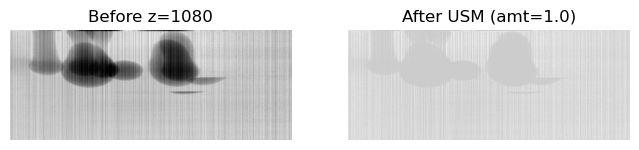

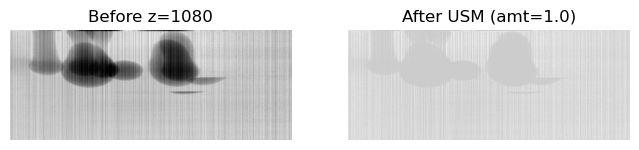

Tune SIGMA_USM (sets feature scale), AMOUNT_USM (sharpen), THR_USM (~0.01 to avoid noise boosting).


In [4]:
files = list_files_gray(USM_DATA_DIR)
idxs = choose_middle_indices(len(files), USM_K_PREVIEW)

volK = np.stack([to_float01(read_slice_gray(files[k]))[0] for k in idxs], axis=0).astype(np.float32)
denK = usm3d_cupy(volK, sigma=SIGMA_USM, amount=AMOUNT_USM, threshold=THR_USM)

for ii in [len(idxs)//2, min(len(idxs)//2+1, len(idxs)-1)]:
    show_pair(volK[ii], denK[ii], f"Before z={idxs[ii]}", f"After USM (amt={AMOUNT_USM})")

for i, z in enumerate(idxs):
    s = read_slice_gray(files[z])
    out_u = from_float01(denK[i], {"dtype": s.dtype, "scale": (255.0 if s.dtype==np.uint8 else 65535.0)})
    iio.imwrite(os.path.join(OUT_USM_PREV, f"slice_{z:04d}_usm.tif"), out_u)

print("Tune SIGMA_USM (sets feature scale), AMOUNT_USM (sharpen), THR_USM (~0.01 to avoid noise boosting).")


# Cell 5.3 — 3D Unsharp Mask: full dataset (Z-slab streaming)
Applies USM to the whole stack with Gaussian overlap; saves outputs per slice.


In [21]:
files = list_files_gray(USM_DATA_DIR)
# Overlap in Z ~ 3*sigma_z for Gaussian blur support
ovl_z = int(math.ceil(3.0 * (SIGMA_USM[0] if isinstance(SIGMA_USM, tuple) else SIGMA_USM)))

for z0 in tqdm(range(0, len(files), USM_SLAB), desc="USM3D full"):
    z1 = min(z0 + USM_SLAB, len(files))
    zs = max(0, z0 - ovl_z); ze = min(len(files), z1 + ovl_z)

    slab = np.stack([to_float01(read_slice_gray(p))[0] for p in files[zs:ze]], axis=0).astype(np.float32)
    den_ext = usm3d_cupy(slab, sigma=SIGMA_USM, amount=AMOUNT_USM, threshold=THR_USM)
    core = den_ext[(z0 - zs):(z1 - zs)]

    for i, z in enumerate(range(z0, z1)):
        s = read_slice_gray(files[z])
        out_u = from_float01(core[i], {"dtype": s.dtype, "scale": (255.0 if s.dtype==np.uint8 else 65535.0)})
        iio.imwrite(os.path.join(OUT_USM_FULL, f"slice_{z:04d}.tif"), out_u)

print("USM full output:", OUT_USM_FULL)


USM3D full: 100%|████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:19<00:00,  2.00s/it]

USM full output: /home/askiran/data/C_division_65825//PnP_lambda_pt2_200iterations/_usm3d_full


# Cell 6 — Bilateral Filtering (3D)

**Idea.** Bilateral filter = Gaussian blur that refuses to mix very different intensities.
It smooths within regions but doesn’t smear across edges: spatial Gaussian (σ_s) × range Gaussian (σ_r)

**Params**
- `BIL_SIGMA_S=(sz,sy,sx)` — spatial stddev (voxels).
- `BIL_RADIUS=(rz,ry,rx)` — support; default `≈ ceil(2.5*σ_s)` per axis.
- `BIL_SIGMA_R` — range stddev in **[0,1]** intensity units.
- `BIL_SLAB` — core Z per pass.
- **Z-Overlap**: `ovl_z = rz`.

**Notes.** Costs scale with volume × window size. Use modest radii (e.g., `(1,2,2)` or `(2,3,3)`), especially in 3D.


# Cell 6.1 — Prereqs: Bilateral

In [10]:
# ===== Bilateral 3D — prereqs =====
BILAT_DATA_DIR  = "/home/askiran/data/Normalized_log"
BILAT_K_PREVIEW = 2
BILAT_R = (6,6,6)            # radius (rz,ry,rx). Keep modest (e.g., 1,2,2)
BILAT_SIGMA_S = (2.0, 2.0, 2.0)  # spatial sigma in voxels (z,y,x)
BILAT_SIGMA_R = 0.30         # range sigma in [0,1] intensities
BILAT_SLAB = 64
OUT_BILAT_PREV = f"{BILAT_DATA_DIR.rstrip('/')}/_bilat3d_preview"
OUT_BILAT_FULL = f"{BILAT_DATA_DIR.rstrip('/')}/_bilat3d_full"
os.makedirs(OUT_BILAT_PREV, exist_ok=True); os.makedirs(OUT_BILAT_FULL, exist_ok=True)

def _triple(v): return (v,v,v) if isinstance(v,(int,float)) else v

def bilateral3d_cupy(vol_f01, radius=(1,2,2), sigma_s=(1,2,2), sigma_r=0.1):
    """Naive 3D bilateral: weights = exp(-dI^2/(2σr^2) - ds^2/(2σs^2))"""
    rz,ry,rx = map(int,_triple(radius)); sz,sy,sx = map(float,_triple(sigma_s))
    x = cp.asarray(vol_f01, dtype=cp.float32)
    acc_num = cp.zeros_like(x); acc_den = cp.zeros_like(x)
    two_sr2 = 2.0*(sigma_r**2)
    # precompute spatial terms per offset
    for dz in range(-rz, rz+1):
        for dy in range(-ry, ry+1):
            for dx in range(-rx, rx+1):
                ds2 = (dz/sz)**2 + (dy/sy)**2 + (dx/sx)**2
                w_s = cp.exp(cp.float32(-0.5*ds2))
                y = cp.roll(x, (dz,dy,dx), axis=(0,1,2))
                dI2 = (y - x)**2
                w = w_s * cp.exp(-dI2 / two_sr2)
                acc_num += w * y
                acc_den += w
    out = acc_num / cp.maximum(acc_den, cp.finfo(cp.float32).eps)
    return cp.asnumpy(cp.clip(out, 0.0, 1.0))

# Cell 6.2 — Bilateral: preview on ~10 slices

Bilateral preview metrics: {'score': 1.0241066926139422, 'noise_reduction': 1.6986247673498385, 'edge_retention': 0.012329580510097367, 'var_before': 0.003569666761904955, 'var_after': 0.002101504011079669}


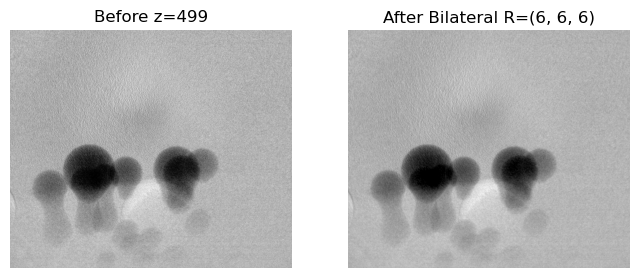

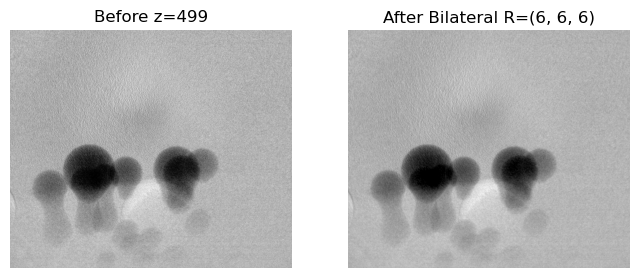

Preview → /home/askiran/data/Normalized_log/_bilat3d_preview


In [11]:
files = list_files_gray(BILAT_DATA_DIR)
idxs = choose_middle_indices(len(files), BILAT_K_PREVIEW)
volK = np.stack([to_float01(read_slice_gray(files[k]))[0] for k in idxs], 0).astype(np.float32)

denK = bilateral3d_cupy(volK, radius=BILAT_R, sigma_s=BILAT_SIGMA_S, sigma_r=BILAT_SIGMA_R)
qm = quality_metrics_3d(volK, denK); print("Bilateral preview metrics:", qm)

for ii in [len(idxs)//2, min(len(idxs)//2+1, len(idxs)-1)]:
    show_pair(volK[ii], denK[ii], f"Before z={idxs[ii]}", f"After Bilateral R={BILAT_R}")

for i,z in enumerate(idxs):
    s = read_slice_gray(files[z])
    out_u = from_float01(denK[i], {"dtype": s.dtype, "scale": 255.0 if s.dtype==np.uint8 else 65535.0})
    iio.imwrite(os.path.join(OUT_BILAT_PREV, f"slice_{z:04d}_bilat.tif"), out_u)
print("Preview →", OUT_BILAT_PREV)


# Cell 6.3 — Bilateral:slab full dataset

In [ ]:
files = list_files_gray(BILAT_DATA_DIR)
Z = len(files)
ovl_z = int(BILAT_R[0])

for z0 in range(0, Z, BILAT_SLAB):
    z1 = min(z0 + BILAT_SLAB, Z)
    zs = max(0, z0 - ovl_z); ze = min(Z, z1 + ovl_z)
    slab = np.stack([to_float01(read_slice_gray(p))[0] for p in files[zs:ze]], 0).astype(np.float32)
    den_ext = bilateral3d_cupy(slab, radius=BILAT_R, sigma_s=BILAT_SIGMA_S, sigma_r=BILAT_SIGMA_R)
    core = den_ext[(z0 - zs):(z1 - zs)]
    for i,z in enumerate(range(z0,z1)):
        s = read_slice_gray(files[z])
        out_u = from_float01(core[i], {"dtype": s.dtype, "scale": 255.0 if s.dtype==np.uint8 else 65535.0})
        iio.imwrite(os.path.join(OUT_BILAT_FULL, f"slice_{z:04d}.tif"), out_u)
print("Full Bilateral →", OUT_BILAT_FULL)

# Cell 7 — Gaussian Filtering (3D)

**Idea.** Convolution with separable 3D Gaussian (edge-aware? no). Fast, linear, baseline.

**Params**
- `GAUSS_SIGMA=(σz,σy,σx)` in voxels; float.
- `GAUSS_SLAB` — core Z per pass.
- **Z-Overlap**: `ovl_z = ceil(3*σz)` (≈ 99.7% mass).

**Notes.** Use anisotropic σ if Z spacing differs (e.g., larger σz when Δz≫Δx,Δy gives more through-plane smoothing).


# Cell 7.1 — Prereqs: Gaussian

In [ ]:
# ===== 3D GAUSSIAN — PREREQS =====
GAUSS_DATA_DIR  = "/home/askiran/data/Normalized_log/_median3d_full"
GAUSS_K_PREVIEW = 2
GAUSS_SIGMA = (1.5, 0, 0)  # (σz,σy,σx) in voxels; set σz=0 for 2D
GAUSS_SLAB = 128
OUT_GAUSS_PREV = f"{GAUSS_DATA_DIR.rstrip('/')}/_gauss3d_preview"
OUT_GAUSS_FULL = f"{GAUSS_DATA_DIR.rstrip('/')}/_gauss3d_full"
os.makedirs(OUT_GAUSS_PREV, exist_ok=True); os.makedirs(OUT_GAUSS_FULL, exist_ok=True)

def gaussian3d_cupy(vol_f01, sigma=(1,1,1)):
    x = cp.asarray(vol_f01, dtype=cp.float32)
    y = cnd.gaussian_filter(x, sigma=tuple(map(float,sigma)), mode='reflect')
    return cp.asnumpy(y.clip(0,1))

# Cell 7.2 — Gaussian: preview on ~10 slices

In [ ]:
files = list_files_gray(GAUSS_DATA_DIR)
idxs = choose_middle_indices(len(files), GAUSS_K_PREVIEW)
volK = np.stack([to_float01(read_slice_gray(files[k]))[0] for k in idxs], 0).astype(np.float32)

denK = gaussian3d_cupy(volK, sigma=GAUSS_SIGMA)
qm = quality_metrics_3d(volK, denK); print("Gaussian preview metrics:", qm)

for ii in [len(idxs)//2, min(len(idxs)//2+1, len(idxs)-1)]:
    show_pair(volK[ii], denK[ii], f"Before z={idxs[ii]}", f"After Gaussian σ={GAUSS_SIGMA}")

for i,z in enumerate(idxs):
    s = read_slice_gray(files[z])
    out_u = from_float01(denK[i], {"dtype": s.dtype, "scale": 255.0 if s.dtype==np.uint8 else 65535.0})
    iio.imwrite(os.path.join(OUT_GAUSS_PREV, f"slice_{z:04d}_gauss.tif"), out_u)
print("Preview →", OUT_GAUSS_PREV)

# Cell 7.3 — Gaussian: slab full dataset

In [ ]:
files = list_files_gray(GAUSS_DATA_DIR)
Z = len(files)
ovl_z = int(np.ceil(3*GAUSS_SIGMA[0])) if GAUSS_SIGMA[0] > 0 else 0

for z0 in range(0, Z, GAUSS_SLAB):
    z1 = min(z0 + GAUSS_SLAB, Z)
    zs = max(0, z0 - ovl_z); ze = min(Z, z1 + ovl_z)
    slab = np.stack([to_float01(read_slice_gray(p))[0] for p in files[zs:ze]], 0).astype(np.float32)
    den_ext = gaussian3d_cupy(slab, sigma=GAUSS_SIGMA)
    core = den_ext[(z0 - zs):(z1 - zs)]
    for i,z in enumerate(range(z0,z1)):
        s = read_slice_gray(files[z])
        out_u = from_float01(core[i], {"dtype": s.dtype, "scale": 255.0 if s.dtype==np.uint8 else 65535.0})
        iio.imwrite(os.path.join(OUT_GAUSS_FULL, f"slice_{z:04d}.tif"), out_u)
print("Full Gaussian →", OUT_GAUSS_FULL)

# Cells 8 — Wiener Filtering (Local, 3D)

**Idea.** Estimate local mean/variance in a sliding 3D window and shrink towards the mean:
\[
\hat{u} = \mu + \frac{\max(\sigma^2 - \sigma_n^2, 0)}{\max(\sigma^2,\varepsilon)} \,(x-\mu),
\]
where \(\mu,\sigma^2\) are local stats; \(\sigma_n^2\) is noise variance (auto or user).

**Params**
- `WIEN_SIZE=(kz,ky,kx)` (odd) — neighborhood window.
- `WIEN_NOISE=None|"auto"|float` — noise variance estimate (in [0,1] range); `"auto"` uses median local variance.
- `WIEN_SLAB` — core Z-slices per pass.
- **Z-Overlap**: `ovl_z = floor(kz/2)`.

**When to use.** Moderately stationary noise; preserves edges better than plain mean. Very fast on GPU via box filters.


# Cell 8.1 — Prereqs: Wiener

In [12]:
# ===== 3D WIENER (LOCAL) — PREREQS =====
WIENER_DATA_DIR = "/home/askiran/data/Normalized_log"  # <-- change as needed
WIENER_K_PREVIEW = 2
WIENER_WIN = (3,5,5)     # window (kz,ky,kx), odd each; set kz=1 for 2D per-slice
WIENER_SIGMA_N = None    # noise std; None = auto from local variance median
WIENER_SLAB = 96         # core Z-slices per pass
OUT_WIENER_PREV = f"{WIENER_DATA_DIR.rstrip('/')}/_wiener3d_preview"
OUT_WIENER_FULL = f"{WIENER_DATA_DIR.rstrip('/')}/_wiener3d_full"
os.makedirs(OUT_WIENER_PREV, exist_ok=True); os.makedirs(OUT_WIENER_FULL, exist_ok=True)

def _odd3(s):
    s = (s,s,s) if isinstance(s,int) else tuple(s)
    return tuple(int(v)|1 for v in s)

def wiener3d_local_cupy(vol_f01, win=(3,5,5), sigma_n=None, eps=1e-8):
    """Local Wiener: u = m + max(var - n2,0)/max(var,eps) * (x - m)"""
    win = _odd3(win)
    x = cp.asarray(vol_f01, dtype=cp.float32)
    m  = cnd.uniform_filter(x, size=win, mode='reflect')
    m2 = cnd.uniform_filter(x*x, size=win, mode='reflect')
    var = cp.maximum(m2 - m*m, 0.0)
    if sigma_n is None:
        n2 = cp.median(var)   # robust global estimate
    else:
        n2 = cp.float32(sigma_n)**2
    g = cp.maximum(var - n2, 0.0) / cp.maximum(var, eps)
    u = m + g * (x - m)
    return cp.asnumpy(cp.clip(u, 0.0, 1.0))


# Cell 8.2 — Wiener: preview on ~10 slices

Wiener preview metrics: {'score': 1.0102087587418647, 'noise_reduction': 1.6157906002430071, 'edge_retention': 0.10183599649015121, 'var_before': 0.003569666761904955, 'var_after': 0.002209238475188613}


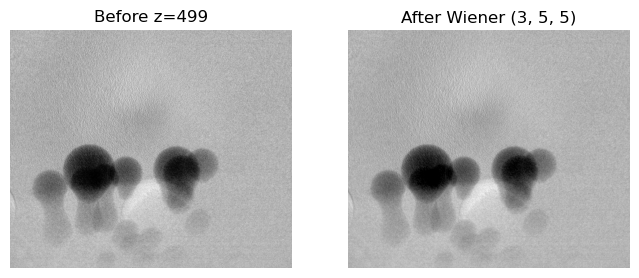

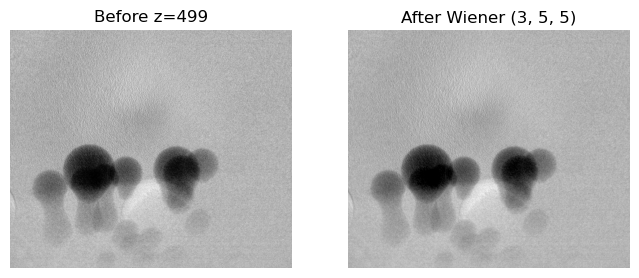

Preview → /home/askiran/data/Normalized_log/_wiener3d_preview


In [13]:
files = list_files_gray(WIENER_DATA_DIR)
idxs = choose_middle_indices(len(files), WIENER_K_PREVIEW)
volK = np.stack([to_float01(read_slice_gray(files[k]))[0] for k in idxs], 0).astype(np.float32)

denK = wiener3d_local_cupy(volK, win=WIENER_WIN, sigma_n=WIENER_SIGMA_N)
qm = quality_metrics_3d(volK, denK); print("Wiener preview metrics:", qm)

for ii in [len(idxs)//2, min(len(idxs)//2+1, len(idxs)-1)]:
    show_pair(volK[ii], denK[ii], f"Before z={idxs[ii]}", f"After Wiener {WIENER_WIN}")

for i,z in enumerate(idxs):
    s = read_slice_gray(files[z])
    out_u = from_float01(denK[i], {"dtype": s.dtype, "scale": 255.0 if s.dtype==np.uint8 else 65535.0})
    iio.imwrite(os.path.join(OUT_WIENER_PREV, f"slice_{z:04d}_wiener.tif"), out_u)
print("Preview →", OUT_WIENER_PREV)

# Cell 8.3 — Wiener: slab full dataset

In [ ]:
files = list_files_gray(WIENER_DATA_DIR)
Z = len(files)
ovl_z = WIENER_WIN[0]//2

for z0 in range(0, Z, WIENER_SLAB):
    z1 = min(z0 + WIENER_SLAB, Z)
    zs = max(0, z0 - ovl_z); ze = min(Z, z1 + ovl_z)
    slab = np.stack([to_float01(read_slice_gray(p))[0] for p in files[zs:ze]], 0).astype(np.float32)
    den_ext = wiener3d_local_cupy(slab, win=WIENER_WIN, sigma_n=WIENER_SIGMA_N)
    core = den_ext[(z0 - zs):(z1 - zs)]
    for i,z in enumerate(range(z0,z1)):
        s = read_slice_gray(files[z])
        out_u = from_float01(core[i], {"dtype": s.dtype, "scale": 255.0 if s.dtype==np.uint8 else 65535.0})
        iio.imwrite(os.path.join(OUT_WIENER_FULL, f"slice_{z:04d}.tif"), out_u)
print("Full Wiener →", OUT_WIENER_FULL)


# Cell 9 FFT Filters (3D / 2D) — Quick Reference

## 1) What these filters do
FFT-domain filtering multiplies the Fourier transform of your volume by a **frequency mask**:
\[
\hat{u}(\mathbf{f}) = \hat{v}(\mathbf{f}) \cdot M(\mathbf{f})
\quad\Rightarrow\quad
u = v * h
\]
where \(M\) is the mask (low/high/band pass), and \(h\) is its spatial impulse response. **Sharper masks ⇢ longer spatial tails** (more ringing; need larger overlap when tiling).

---

## 2) Coordinate system & units
- Volume shape: **(Z, Y, X)**.  
- Voxel spacing \( \Delta = (d_z, d_y, d_x) \) in physical units (e.g., µm).  
- Frequency grids (cycles per unit): `fftfreq(N, d)` gives \([-1/(2d), 1/(2d))\).  
- **Nyquist per-axis**: \(f_{N,z}=1/(2d_z)\), \(f_{N,y}=1/(2d_y)\), \(f_{N,x}=1/(2d_x)\).  
- **Radial frequency**: \( f_r = \sqrt{f_z^2 + f_y^2 + f_x^2} \).  
- If spacing is unknown, use \(\Delta=(1,1,1)\) (cycles per pixel/voxel).

---

## 3) Modes
- **3D mode**: true 3D FFT over (Z,Y,X). Best fidelity; highest VRAM.  
- **2D mode**: per-slice FFT over (Y,X). Lower VRAM; no Z coupling; easiest to stream.

---

## 4) Pass types & mask families
**Pass types**
- **Low-pass**: keep large structures; cutoff \(f_{\text{hi}}\).
- **High-pass**: keep fine detail; cutoff \(f_{\text{lo}}\).
- **Band-pass**: keep \( f_{\text{lo}} \le f_r \le f_{\text{hi}} \).

**Mask families (choose one)**
- **Ideal (brick-wall)**: hard cutoff. Max ringing (Gibbs), infinite support → avoid tiling if possible.
- **Butterworth (order \(n\))**: smooth roll-off. Higher \(n\) = steeper edge, longer tails (needs more overlap).
- **Gaussian**: smoothest; fastest tail decay; most tile-friendly.

---

## 5) Choosing cutoffs
Two equivalent ways:

**A) Nyquist fractions (no physical units):**
- Pick \( \eta \in (0,1] \).  
- Low-pass: \( f_{\text{hi}} = \eta \cdot \min(f_{N,z}, f_{N,y}, f_{N,x}) \).  
- High-pass: \( f_{\text{lo}} = \eta \cdot \min(\cdot) \).

**B) Physical wavelengths (recommended if spacing known):**
- To **keep** features ≥ \(L\): set low-pass \( f_{\text{hi}} \approx 1/L \).  
- To **remove** trends ≥ \(L\): set high-pass \( f_{\text{lo}} \approx 1/L \).  
- For **band-pass** targeting sizes in \([L_{\min}, L_{\max}]\):  
  \( f_{\text{lo}} \approx 1/L_{\max}, \; f_{\text{hi}} \approx 1/L_{\min} \).

**Good starting points**
- Denoise fine speckle: Butterworth **low-pass**, order 2, \( \eta \approx 0.20\!-\!0.30 \).  
- Background flattening: Butterworth **high-pass**, order 2, \( \eta \approx 0.05\!-\!0.10 \).  
- Structure banding: Butterworth **band-pass**, order 2, set \([f_{\text{lo}}, f_{\text{hi}}]\) from size range.

---

## 6) Slabbed full-volume processing (to reduce memory)
Filtering in frequency equals **convolution** with kernel \(h\). When streaming in **Z-slabs**, add **Z-overlap** large enough to capture the effective support of \(h\).

**Rule of thumb for Z-overlap**
1. Pick effective cutoff \( f_{\text{eff}} \):
   - Low-pass: \( f_{\text{eff}} = f_{\text{hi}} \)
   - High-pass: \( f_{\text{eff}} = f_{\text{lo}} \)
   - Band-pass: \( f_{\text{eff}} = \min(f_{\text{lo}}, f_{\text{hi}}) \)
2. Choose \(k\) by mask smoothness:
   - Gaussian: \(k \approx 3\)
   - Butterworth (order 2–4): \(k \approx 5\!-\!8\)  (higher order ⇒ bigger \(k\))
   - Ideal: **avoid slab tiling**; if forced, very large \(k\) (often impractical)
3. Convert to overlap in **slices**:
\[
L \approx \frac{k}{f_{\text{eff}}} \quad\Rightarrow\quad
\text{ovl}_z = \left\lceil \frac{L}{d_z} \right\rceil
\]
Clamp to a sane range (e.g., 2…128). Increase if you see seams.

**Slab algorithm (Z streaming)**
- Core window: `[z0:z1)` of length **SLAB** (slices to output this pass).  
- Read extended: `[zs:ze)` with `zs=z0-ovl_z`, `ze=z1+ovl_z` clipped to `[0,Z)`.  
- FFT-filter the **extended** slab (3D FFT).  
- Crop back to core and save.  
- Advance `z0 ← z1` and repeat.

> For **2D mode**, ovl\_z = 0 (no Z context), so slabs can be large.

---

## 7) Practical notes & pitfalls
- **Ringing**: Sharper masks (Ideal, high-order Butterworth) ⇒ halos near edges & seams. Prefer Gaussian or order-2 Butterworth for microscopy-like data.  
- **Padding**: FFT assumes periodic boundaries. Mirror-padding before FFT can reduce edge ringing if you process the **entire** volume; for slabs we rely on overlap.  
- **Memory**: 3D FFT needs ~2–3× slab size in VRAM (complex spectra + temporaries). Reduce **SLAB** if you hit OOM.  
- **2D vs 3D**: 2D is faster/safer; use when through-plane correlations are weak or Z anisotropy is high.  
- **Evaluation**: Use your existing `quality_metrics_3d` (noise reduction in flats, edge retention on gradients) and visual checks on 2–3 representative slices.

---

## 8) Parameters (summary)
- `FILTER_KIND`: `"ideal" | "butter" | "gauss"`  
- `PASS_TYPE`: `"low" | "high" | "band"`  
- `ORDER_BUTTER`: 1–4 (steepness; 2 is a good default)  
- `SPACING=(d_z,d_y,d_x)`: voxel size (set `(1,1,1)` if unknown)  
- Cutoffs: **either** Nyquist fractions (`F_*_NYQ`) **or** absolute (`F_*_ABS`, cycles/unit)  
- `FFT_MODE`: `"3d"` (preferred if VRAM allows) or `"2d"`  
- `SLAB`: core slices per pass (e.g., 64)  
- `ovl_z`: computed from \(k, f_{\text{eff}}, d_z\) (see §6)

---

## 9) cuFFT dependency (CuPy)
- `cp.fft.*` requires **cuFFT** (e.g., `libcufft.so.11` for CUDA-12).  
- Minimal check (avoid `cp.random`, which needs cuRAND):
  ```python
  import cupy as cp, numpy as np
  x = cp.asarray(np.random.rand(8,8,8).astype(np.float32))  # NumPy RNG -> GPU
  ok = float(cp.abs(cp.fft.ifftn(cp.fft.fftn(x)).real - x).max()) < 1e-5
  print("cuFFT OK:", ok)


# Cell 9.1 —Prereqs: 3D FFT filters (choose input path & parameters)

In [21]:
# ===== CONFIG: 3D FFT FILTERS =====
FFT_DATA_DIR   = "/home/askiran/data/Normalized_log"   # <-- change per dataset
FFT_K_PREVIEW  = 10                                       # ~10 middle slices
FFT_MODE       = "3d"                                     # "3d" or "2d" (2D = per-slice FFT)
FILTER_KIND    = "butter"                                 # "ideal", "butter", "gauss"
PASS_TYPE      = "low"                                    # "low", "high", or "band"
ORDER_BUTTER   = 2                                        # Butterworth order (1..4 typical)
SPACING        = (1.0, 10.0, 1.0)                          # voxel spacing (dz,dy,dx)

# Choose cutoffs via Nyquist fractions (easy) OR absolute freq (cycles per unit):
USE_NYQUIST    = True
F_HI_NYQ       = 0.25     # e.g., keep features > ~4 px (low-pass at 0.25*Nyquist)
F_LO_NYQ       = 0.05     # used only if PASS_TYPE is "high" or "band"

# Absolute frequencies (cycles per unit); set to None when using Nyquist fractions
F_HI_ABS       = None
F_LO_ABS       = None

# Output folders
OUT_FFT_PREV   = f"{FFT_DATA_DIR.rstrip('/')}/_fft_preview"
OUT_FFT_FULL   = f"{FFT_DATA_DIR.rstrip('/')}/_fft_full"

# ===== Imports (uses helpers from your Cell 1) =====
import os, numpy as np, cupy as cp
import imageio.v3 as iio
from glob import glob

os.makedirs(OUT_FFT_PREV, exist_ok=True)
os.makedirs(OUT_FFT_FULL, exist_ok=True)

# ---- cuFFT quick check (tiny FFT). If this fails, install cuFFT and restart Jupyter. ----
try:
    _tmp = cp.asarray(np.random.rand(4,4,4).astype(np.float32))
    _ = cp.fft.fftn(_tmp); del _tmp, _
    print("cuFFT: OK")
except Exception as e:
    raise RuntimeError(
        "cuFFT not available. Install it with:\n"
        "  pip install -U nvidia-cufft-cu12\n"
        "Then restart JupyterLab from the same terminal."
    ) from e

# ===== Frequency-grid & masks =====
def _freq_grid_3d(z, y, x, spacing=(1.0,1.0,1.0)):
    dz, dy, dx = spacing
    fz = cp.fft.fftfreq(z, d=dz)[:,None,None]
    fy = cp.fft.fftfreq(y, d=dy)[None,:,None]
    fx = cp.fft.fftfreq(x, d=dx)[None,None,:]
    fr = cp.sqrt(fz*fz + fy*fy + fx*fx)
    return fz, fy, fx, fr

def _freq_grid_2d(y, x, spacing_yx=(1.0,1.0)):
    dy, dx = spacing_yx
    fy = cp.fft.fftfreq(y, d=dy)[None,:,None]
    fx = cp.fft.fftfreq(x, d=dx)[None,None,:]
    fr = cp.sqrt(fy*fy + fx*fx)
    return fy, fx, fr

def ideal_mask(fr, f_lo=None, f_hi=None):
    m = cp.ones_like(fr, dtype=cp.float32)
    if f_hi is not None: m = m * (fr <= f_hi)
    if f_lo is not None: m = m * (fr >= f_lo)
    return m.astype(cp.float32)

def butterworth_mask(fr, f_lo=None, f_hi=None, order=2):
    eps = cp.float32(1e-12)
    if f_hi is not None and f_lo is None:   # low-pass
        return (1.0 / (1.0 + (fr/(f_hi+eps))**(2*order))).astype(cp.float32)
    if f_lo is not None and f_hi is None:   # high-pass
        return (1.0 - 1.0/(1.0 + (fr/(f_lo+eps))**(2*order))).astype(cp.float32)
    # band-pass
    lp = 1.0 / (1.0 + (fr/(f_hi+eps))**(2*order))
    hp = 1.0 - 1.0/(1.0 + (fr/(f_lo+eps))**(2*order))
    return (lp*hp).astype(cp.float32)

def gaussian_mask(fr, f0, bandwidth=None, kind="low"):
    eps = cp.float32(1e-12)
    if kind=="low":  return cp.exp(- (fr/(f0+eps))**2).astype(cp.float32)
    if kind=="high": return (1.0 - cp.exp(- (fr/(f0+eps))**2)).astype(cp.float32)
    if kind=="band":
        assert bandwidth is not None and bandwidth>0
        return cp.exp(- ((fr - f0)**2) / (2.0*(bandwidth+eps)**2)).astype(cp.float32)
    raise ValueError("kind must be 'low','high','band'")

def build_cutoffs(spacing, use_nyq, f_lo_nyq, f_hi_nyq, f_lo_abs, f_hi_abs):
    # Nyquist per axis (cycles per unit)
    nyq_z = 1.0/(2*spacing[0]); nyq_y = 1.0/(2*spacing[1]); nyq_x = 1.0/(2*spacing[2])
    nyq_min = min(nyq_z, nyq_y, nyq_x)
    if use_nyq:
        f_lo = (f_lo_nyq * nyq_min) if f_lo_nyq is not None else None
        f_hi = (f_hi_nyq * nyq_min) if f_hi_nyq is not None else None
    else:
        f_lo = f_lo_abs; f_hi = f_hi_abs
    return f_lo, f_hi, nyq_min

def build_mask(fr, kind, pass_type, f_lo, f_hi, order=2):
    if kind=="ideal":
        if pass_type=="low":  return ideal_mask(fr, f_hi=f_hi)
        if pass_type=="high": return ideal_mask(fr, f_lo=f_lo)
        if pass_type=="band": return ideal_mask(fr, f_lo=f_lo, f_hi=f_hi)
    elif kind=="butter":
        if pass_type=="low":  return butterworth_mask(fr, f_hi=f_hi, order=order)
        if pass_type=="high": return butterworth_mask(fr, f_lo=f_lo, order=order)
        if pass_type=="band": return butterworth_mask(fr, f_lo=f_lo, f_hi=f_hi, order=order)
    elif kind=="gauss":
        if pass_type=="low":  return gaussian_mask(fr, f0=f_hi, kind="low")
        if pass_type=="high": return gaussian_mask(fr, f0=f_lo, kind="high")
        if pass_type=="band": return gaussian_mask(fr, f0=(f_lo+f_hi)/2.0, bandwidth=(f_hi-f_lo)/2.5, kind="band")
    raise ValueError("Invalid FILTER_KIND/PASS_TYPE combination")

def fft_filter_3d(vol_f32, mask, shift=False):
    F = cp.fft.fftn(vol_f32)
    if shift:
        F = cp.fft.fftshift(F)
        G = cp.fft.ifftshift(F * mask)
    else:
        G = F * mask
    out = cp.fft.ifftn(G).real.astype(cp.float32)
    return out

def fft_filter_2d_slicewise(vol_f32, mask2d):
    Z, Y, X = vol_f32.shape
    out = cp.empty_like(vol_f32)
    for z in range(Z):
        F = cp.fft.fft2(vol_f32[z])
        G = F * mask2d
        out[z] = cp.fft.ifft2(G).real
    return out.astype(cp.float32)


cuFFT: OK


# Cell 9.2 — FFT preview on ~10 middle slices (tune cutoffs/order)

Nyquist(min-axis)=0.050000 cyc/unit | Using f_lo=0.0025000000000000005 , f_hi=0.0125


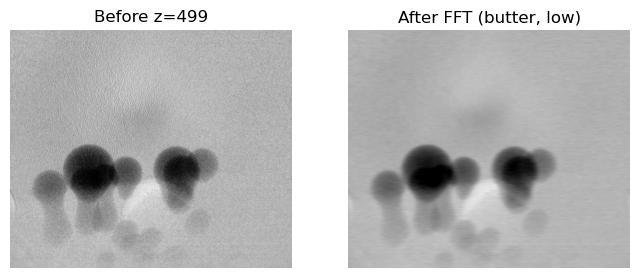

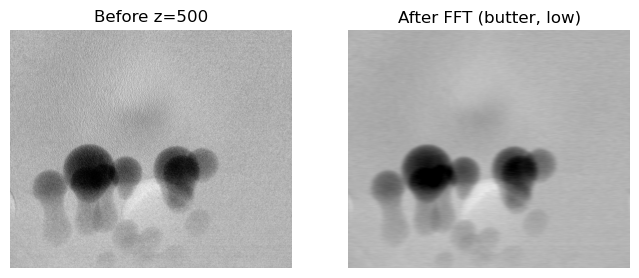

Preview written to: /home/askiran/data/Normalized_log/_fft_preview


In [22]:
# Uses helpers from Cell 1: list_files_gray, read_slice_gray, to_float01, from_float01, choose_middle_indices, show_pair

files = list_files_gray(FFT_DATA_DIR)
idxs = choose_middle_indices(len(files), FFT_K_PREVIEW)

# Build preview block (float [0,1])
volK = np.stack([to_float01(read_slice_gray(files[k]))[0] for k in idxs], axis=0).astype(np.float32)
Z, Y, X = volK.shape
volK_gpu = cp.asarray(volK)

# Determine cutoffs
f_lo, f_hi, nyq = build_cutoffs(SPACING, USE_NYQUIST, F_LO_NYQ, F_HI_NYQ, F_LO_ABS, F_HI_ABS)
print(f"Nyquist(min-axis)={nyq:.6f} cyc/unit | Using f_lo={f_lo} , f_hi={f_hi}")

# Build mask(s) and apply
if FFT_MODE.lower() == "3d":
    _,_,_, fr = _freq_grid_3d(Z, Y, X, spacing=SPACING)
    M = build_mask(fr, FILTER_KIND.lower(), PASS_TYPE.lower(), f_lo, f_hi, order=ORDER_BUTTER)
    denK_gpu = fft_filter_3d(volK_gpu, M, shift=False)
else:  # 2D per slice
    _,_, fr2 = _freq_grid_2d(Y, X, spacing_yx=(SPACING[1], SPACING[2]))
    M2 = build_mask(fr2, FILTER_KIND.lower(), PASS_TYPE.lower(), f_lo, f_hi, order=ORDER_BUTTER)
    denK_gpu = fft_filter_2d_slicewise(volK_gpu, M2)

denK = cp.asnumpy(denK_gpu)

# Show two slices with matched display window
for ii in [len(idxs)//2, min(len(idxs)//2+1, len(idxs)-1)]:
    show_pair(volK[ii], denK[ii], f"Before z={idxs[ii]}", f"After FFT ({FILTER_KIND}, {PASS_TYPE})")

# Save preview (preserve dtype/size)
for i, z in enumerate(idxs):
    s = read_slice_gray(files[z])
    out_u = from_float01(denK[i], {"dtype": s.dtype, "scale": (255.0 if s.dtype==np.uint8 else 65535.0)})
    iio.imwrite(os.path.join(OUT_FFT_PREV, f"slice_{z:04d}_fft.tif"), out_u)

print("Preview written to:", OUT_FFT_PREV)


# Cell 9.3 — 3D FFT full dataset with Z-slabs + automatic overlap 

In [ ]:
# Requires: functions from F-1 (build_cutoffs, build_mask, _freq_grid_3d, fft_filter_3d)
# Requires: IO helpers from Cell 1 (list_files_gray, read_slice_gray, to_float01, from_float01)

import math

FFT_SLAB = 64  # core slices per pass (adjust for VRAM)
files = list_files_gray(FFT_DATA_DIR)

# Load shape & CPU volume (float32 [0,1])
vol_all = np.stack([to_float01(read_slice_gray(p))[0] for p in files], axis=0).astype(np.float32)
Z, Y, X = vol_all.shape

# Determine cutoffs
f_lo, f_hi, nyq = build_cutoffs(SPACING, USE_NYQUIST, F_LO_NYQ, F_HI_NYQ, F_LO_ABS, F_HI_ABS)
print(f"Volume {vol_all.shape}, Nyquist(min-axis)={nyq:.6f}, f_lo={f_lo}, f_hi={f_hi}")

# Choose effective cutoff & overlap factor k (heuristic)
pass_type = PASS_TYPE.lower()
kind = FILTER_KIND.lower()
if pass_type == "low":
    f_eff = f_hi
elif pass_type == "high":
    f_eff = f_lo
else:  # band
    f_eff = min(f_lo if f_lo else np.inf, f_hi if f_hi else np.inf)
if f_eff is None or f_eff <= 0:
    raise ValueError("Cutoff not defined. Set F_HI_* for low-pass, F_LO_* for high-pass, both for band-pass.")

k_by_kind = {"gauss": 3.0, "butter": 6.0, "ideal": 12.0}
k = k_by_kind.get(kind, 6.0)
ovl_units_z = k / max(f_eff, 1e-6)          # units
ovl_z = int(math.ceil(ovl_units_z / SPACING[0]))
ovl_z = int(np.clip(ovl_z, 2, 128))         # safety clamp
print(f"Estimated Z-overlap = {ovl_z} slices (k={k}, spacing dz={SPACING[0]})")

# Process in Z-slabs with overlap
for z0 in range(0, Z, FFT_SLAB):
    z1 = min(z0 + FFT_SLAB, Z)
    zs = max(0, z0 - ovl_z)
    ze = min(Z, z1 + ovl_z)

    # Build slab and GPU arrays
    slab = cp.asarray(vol_all[zs:ze])  # (Zs, Y, X)
    Zs = slab.shape[0]

    # Build 3D mask for the slab size
    _,_,_, fr = _freq_grid_3d(Zs, Y, X, spacing=SPACING)
    M = build_mask(fr, kind, pass_type, f_lo, f_hi, order=ORDER_BUTTER)

    # Apply 3D FFT filter on the extended slab
    den_ext = fft_filter_3d(slab, M, shift=False)

    # Crop back to core and save
    core = cp.asnumpy(den_ext[(z0 - zs):(z1 - zs)])
    for i, z in enumerate(range(z0, z1)):
        s = read_slice_gray(files[z])
        out_u = from_float01(core[i], {"dtype": s.dtype, "scale": (255.0 if s.dtype==np.uint8 else 65535.0)})
        iio.imwrite(os.path.join(OUT_FFT_FULL, f"slice_{z:04d}.tif"), out_u)

print("FFT slabbed output →", OUT_FFT_FULL)


# Cells 10 — Guided Filtering (3D, grayscale)

**He et al.** Edge-preserving, halo-free. For grayscale, guidance `I = p`.

Box-filter formulas over window `r=(rz,ry,rx)`:
\[
a = \frac{\mathrm{cov}(I,p)}{\mathrm{var}(I)+\varepsilon},\quad b = \bar{p} - a \bar{I},\quad
q = \overline{a}\,I + \overline{b}
\]

**Params**
- `GUIDE_RADIUS=(rz,ry,rx)` — window radius (voxels).
- `GUIDE_EPS` — regularizer (suggest \(10^{-4}\)–\(10^{-2}\)) in **[0,1]²** units.
- `GUIDE_SLAB` — core Z per pass.
- **Z-Overlap**: `ovl_z = rz`.

**Notes.** Very effective at smoothing while keeping edges; larger radii increase run time linearly.


# Cell 10.1 — Prereqs: Guided filter (3D, GPU)

In [11]:
# ===== 3D GUIDED FILTER — PREREQS =====
GUIDE_DATA_DIR  = "/home/askiran/data/nlm_stacks/7080_2"
GUIDE_K_PREVIEW = 10
GUIDE_R = (1,2,2)     # radius (rz,ry,rx) -> window size (2r+1)
GUIDE_EPS = 1e-3      # regularization (smaller -> preserves edges more)
GUIDE_SLAB = 96
OUT_GUIDE_PREV = f"{GUIDE_DATA_DIR.rstrip('/')}/_guided3d_preview"
OUT_GUIDE_FULL = f"{GUIDE_DATA_DIR.rstrip('/')}/_guided3d_full"
os.makedirs(OUT_GUIDE_PREV, exist_ok=True); os.makedirs(OUT_GUIDE_FULL, exist_ok=True)

def _rad_to_win(r):
    r = (r,r,r) if isinstance(r,int) else tuple(r)
    return tuple(int(2*ri+1) for ri in r)

def guided3d_cupy(I_f01, r=(1,2,2), eps=1e-3, P_f01=None):
    """Self-guided if P_f01 is None; otherwise guide I, filter P."""
    I = cp.asarray(I_f01, dtype=cp.float32)
    P = I if P_f01 is None else cp.asarray(P_f01, dtype=cp.float32)
    size = _rad_to_win(r)

    mean_I  = cnd.uniform_filter(I, size=size, mode='reflect')
    mean_P  = cnd.uniform_filter(P, size=size, mode='reflect')
    corr_I  = cnd.uniform_filter(I*I, size=size, mode='reflect')
    corr_IP = cnd.uniform_filter(I*P, size=size, mode='reflect')

    var_I = cp.maximum(corr_I - mean_I*mean_I, 0.0)
    cov_IP = corr_IP - mean_I*mean_P

    a = cov_IP / (var_I + cp.float32(eps))
    b = mean_P - a*mean_I

    mean_a = cnd.uniform_filter(a, size=size, mode='reflect')
    mean_b = cnd.uniform_filter(b, size=size, mode='reflect')
    q = mean_a * I + mean_b
    return cp.asnumpy(cp.clip(q, 0.0, 1.0))

# Cell 10.2 — Guided: preview 

Guided preview metrics: {'score': 0.8745062956714031, 'noise_reduction': 1.0887451270278312, 'edge_retention': 0.5531480486367608, 'var_before': 0.004440188407897949, 'var_after': 0.004078262485563755}


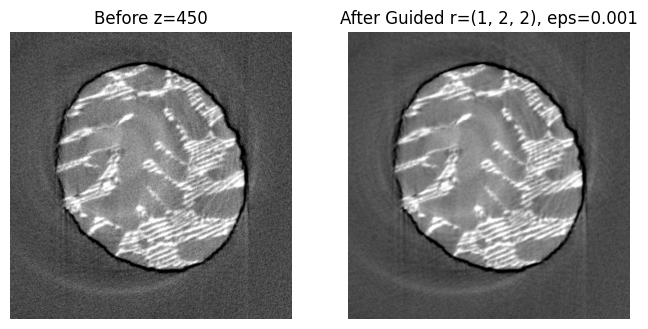

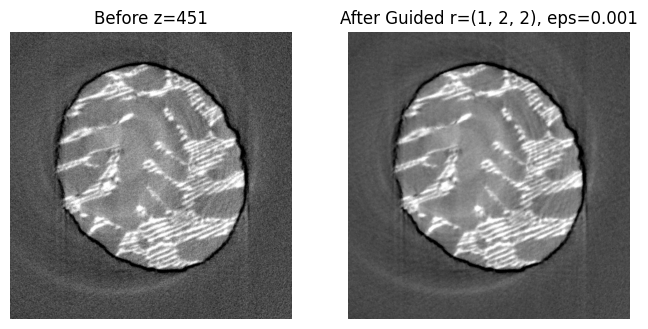

Preview → /home/askiran/data/nlm_stacks/7080_2/_guided3d_preview


In [12]:
files = list_files_gray(GUIDE_DATA_DIR)
idxs = choose_middle_indices(len(files), GUIDE_K_PREVIEW)
volK = np.stack([to_float01(read_slice_gray(files[k]))[0] for k in idxs], 0).astype(np.float32)

denK = guided3d_cupy(volK, r=GUIDE_R, eps=GUIDE_EPS)
qm = quality_metrics_3d(volK, denK); print("Guided preview metrics:", qm)

for ii in [len(idxs)//2, min(len(idxs)//2+1, len(idxs)-1)]:
    show_pair(volK[ii], denK[ii], f"Before z={idxs[ii]}", f"After Guided r={GUIDE_R}, eps={GUIDE_EPS}")

for i,z in enumerate(idxs):
    s = read_slice_gray(files[z])
    out_u = from_float01(denK[i], {"dtype": s.dtype, "scale": 255.0 if s.dtype==np.uint8 else 65535.0})
    iio.imwrite(os.path.join(OUT_GUIDE_PREV, f"slice_{z:04d}_guided.tif"), out_u)
print("Preview →", OUT_GUIDE_PREV)

# Cell 10.3 - Guided: slabbed full data

In [ ]:
files = list_files_gray(GUIDE_DATA_DIR)
Z = len(files)
ovl_z = int(GUIDE_R[0])

for z0 in range(0, Z, GUIDE_SLAB):
    z1 = min(z0 + GUIDE_SLAB, Z)
    zs = max(0, z0 - ovl_z); ze = min(Z, z1 + ovl_z)
    slab = np.stack([to_float01(read_slice_gray(p))[0] for p in files[zs:ze]], 0).astype(np.float32)
    den_ext = guided3d_cupy(slab, r=GUIDE_R, eps=GUIDE_EPS)
    core = den_ext[(z0 - zs):(z1 - zs)]
    for i,z in enumerate(range(z0,z1)):
        s = read_slice_gray(files[z])
        out_u = from_float01(core[i], {"dtype": s.dtype, "scale": 255.0 if s.dtype==np.uint8 else 65535.0})
        iio.imwrite(os.path.join(OUT_GUIDE_FULL, f"slice_{z:04d}.tif"), out_u)
print("Full Guided →", OUT_GUIDE_FULL)

# Cell 11- k-Nearest Neighbour (k-NN) Filter — Parameters & Tuning

**What it does.** For each voxel, look inside a local window and pick the **K** neighbours whose *intensity* is closest to the center; combine them (uniform or distance-weighted) to denoise while preserving edges.

## Parameters
- **Radius `R=(rz,ry,rx)`**: local window is `(2rz+1)×(2ry+1)×(2rx+1)`.  
  • Start with `rz=0` (2D per-slice) for anisotropic Z; use `rz=1` if true 3D context helps.
- **K**: number of nearest neighbours to average. Typical `5–15`. Larger → smoother but risk blur.
- **Metric** (`l1` | `l2`):
  - `l1`: uses absolute difference `|ΔI|`. Robust; good default.
  - `l2`: uses squared difference `ΔI²`. Penalises outliers more strongly.
- **Weighting** (`uniform` | `inverse` | `inverse_sq` | `gaussian`):
  - `uniform`: simple mean over the K neighbours.
  - `inverse`: weights = `1/(d + ε)`; closer neighbours dominate.
  - `inverse_sq`: weights = `1/(d + ε)²`; even stronger emphasis on closest.
  - `gaussian`: weights = `exp(-(d²)/(2σᵣ²))`; smooth, `σᵣ` in intensity units `[0,1]`.
  - Here `d` is the **magnitude** of the distance (for `l2` we use `sqrt(ΔI²)` so it’s comparable).
- **`σᵣ`** (only for `gaussian` weighting): range scale, e.g. `0.05–0.15` for 8-bit-like data in `[0,1]`.
- **`ε`**: small constant to avoid division by zero (default `1e-3`); prevents exploding weights at the center.
- **Tiles** `tile=(Ty,Tx)` and **chunks** `chunk`:
  - Tiling keeps VRAM bounded in YX; chunking processes neighbor offsets in small batches.
  - If you OOM: reduce `Ty/Tx`, reduce `chunk`, or use `rz=0`.

## Overlap for streaming
- Z-overlap: `ovl_z = rz`. Y/X overlaps are handled by tiles internally as `(ry,rx)`.

## Quick presets
- **Sharper edges**: `metric='l1'`, `weighting='inverse'`, `K=7–9`, `R=(0,2,2)`, `ε=1e-3`.
- **Stronger denoise**: `metric='l2'`, `weighting='gaussian'`, `σᵣ=0.08–0.12`, `K=11–15`, `R=(1,2,2)`.
- **Fastest & safe**: `uniform` weighting, small `R`, `K≈7`, `rz=0`.

Evaluate with your `quality_metrics_3d` (noise in flat regions vs edge retention) + visual checks.


# Cell 11.1 -- Prereqs: 3D k-NN (intensity)

In [2]:
# ===== 3D k-NN (INTENSITY) — MEMORY-SAFE WITH METRIC & WEIGHTING =====

KNN_DATA_DIR   = "/home/askiran/data/Normalized_log"   # <-- change per dataset
KNN_K_PREVIEW  = 10

# ---- Core parameters you will tune ----
KNN_R          = (2, 2, 2)      # radius (rz,ry,rx). Use rz=0 for 2D per-slice; rz=1 for true 3D
KNN_K          = 9              # number of nearest neighbours (1..W)
KNN_METRIC     = "l1"           # "l1" (|ΔI|) or "l2" (ΔI^2); l1 is robust default
KNN_WEIGHTING  = "inverse"      # "uniform" | "inverse" | "inverse_sq" | "gaussian"
KNN_W_SIGMA    = 0.10           # for gaussian weighting only (range σ in [0,1])
KNN_W_EPS      = 1e-3           # ε for inverse weightings to avoid singularities

# ---- Performance controls ----
KNN_CHUNK      = 1              # offsets processed at once (1 safest; 2–4 faster if VRAM allows)
KNN_TILE       = (512, 512)     # core YX tile size
KNN_SLAB       = 48             # Z core slices per pass (full run)
OUT_KNN_PREV   = f"{KNN_DATA_DIR.rstrip('/')}/_knn3d_preview"
OUT_KNN_FULL   = f"{KNN_DATA_DIR.rstrip('/')}/_knn3d_full"
os.makedirs(OUT_KNN_PREV, exist_ok=True); os.makedirs(OUT_KNN_FULL, exist_ok=True)

def _neighbor_offsets(rz, ry, rx):
    return [(dz,dy,dx) for dz in range(-rz,rz+1)
                      for dy in range(-ry,ry+1)
                      for dx in range(-rx,rx+1)]

def _knn_local_chunked_gpu(x, rz, ry, rx, K, metric="l1", weighting="uniform",
                           w_sigma=0.1, w_eps=1e-3, chunk=1):
    """
    x: cp.ndarray (Zs, Yp, Xp) float32 in [0,1]
    Maintains the current K best per voxel; processes neighbor offsets in small chunks.
    Stores candidates in float16 to reduce memory, then computes weights in float32.
    """
    Zs, Yp, Xp = x.shape
    offs = _neighbor_offsets(rz, ry, rx)
    W = len(offs)
    K = int(max(1, min(K, W)))

    # keep top-K dists/vals so far
    best_d = cp.full((K, Zs, Yp, Xp), cp.float16(cp.inf))
    best_v = cp.zeros((K, Zs, Yp, Xp), dtype=cp.float16)

    for s in range(0, W, chunk):
        batch = offs[s:s+chunk]

        # neighbors for this batch (C,Zs,Yp,Xp)
        neigh_list = [cp.roll(x, (dz,dy,dx), axis=(0,1,2)) for (dz,dy,dx) in batch]
        Nchunk = cp.stack(neigh_list, axis=0).astype(cp.float16)

        # distance per metric
        if metric == "l2":
            dchunk = (Nchunk - x[None,...])**2       # squared diff
        else:  # "l1"
            dchunk = cp.abs(Nchunk - x[None,...])    # absolute diff

        # merge with current best and keep top-K (smallest d)
        d_all = cp.concatenate([best_d, dchunk], axis=0)
        v_all = cp.concatenate([best_v, Nchunk], axis=0)
        idx = cp.argpartition(d_all, kth=K-1, axis=0)[:K]
        best_d = cp.take_along_axis(d_all, idx, axis=0)
        best_v = cp.take_along_axis(v_all, idx, axis=0)

        del Nchunk, dchunk, d_all, v_all, idx

    # weighting
    if weighting == "uniform":
        out = best_v.mean(axis=0).astype(cp.float32)

    else:
        # convert to float32 for stable weights
        d = best_d.astype(cp.float32)
        v = best_v.astype(cp.float32)

        # convert to distance magnitude for weighting
        if KNN_METRIC == "l2":
            dist_mag = cp.sqrt(cp.maximum(d, 0.0))   # sqrt(ΔI^2) = |ΔI|
        else:
            dist_mag = d

        if weighting == "inverse":
            w = 1.0 / (dist_mag + float(w_eps))
        elif weighting == "inverse_sq":
            w = 1.0 / (dist_mag + float(w_eps))**2
        elif weighting == "gaussian":
            sigma = float(max(w_sigma, 1e-6))
            w = cp.exp(-(dist_mag**2) / (2.0*sigma*sigma))
        else:
            raise ValueError("weighting must be one of: uniform, inverse, inverse_sq, gaussian")

        out = (w * v).sum(axis=0) / cp.maximum(w.sum(axis=0), cp.finfo(cp.float32).eps)

    return out.astype(cp.float32)

def knn3d_intensity_cupy_chunked_tiled(vol_f01, radius=(0,2,2), K=9,
                                       metric="l1", weighting="uniform",
                                       w_sigma=0.1, w_eps=1e-3,
                                       chunk=1, tile=(512,512)):
    """
    Memory-safe wrapper:
      - processes (Zs,Y,X) in YX tiles with overlaps (ry,rx),
      - calls the chunked k-NN on each extended tile,
      - crops back to the core tile and stitches.
    """
    rz, ry, rx = map(int, radius)
    Ty, Tx = map(int, tile)
    x = cp.asarray(vol_f01, dtype=cp.float32)
    Zs, Y, X = x.shape
    oy, ox = ry, rx

    out = cp.empty_like(x)
    for y0 in range(0, Y, Ty):
        y1 = min(y0 + Ty, Y)
        ys = max(0, y0 - oy); ye = min(Y, y1 + oy)
        for x0 in range(0, X, Tx):
            x1 = min(x0 + Tx, X)
            xs = max(0, x0 - ox); xe = min(X, x1 + ox)

            patch = x[:, ys:ye, xs:xe]
            filt  = _knn_local_chunked_gpu(patch, rz, ry, rx, K,
                                           metric=metric, weighting=weighting,
                                           w_sigma=w_sigma, w_eps=w_eps, chunk=chunk)
            out[:, y0:y1, x0:x1] = filt[:, (y0-ys):(y1-ys), (x0-xs):(x1-xs)]
            del patch, filt
    return cp.asnumpy(cp.clip(out, 0.0, 1.0))

# Cell 11.2 - k-NN: preview on ~10 slices

# Note: This stacks all neighbors → VRAM ∝ window size. Keep R small; if you OOM, reduce KNN_SLAB or switch to 2D (rz=0).

kNN preview metrics: {'score': 0.9950888616486021, 'noise_reduction': 1.0131916587970227, 'edge_retention': 0.9679346659259713, 'var_before': 0.0036418591625988483, 'var_after': 0.003594442503526807}


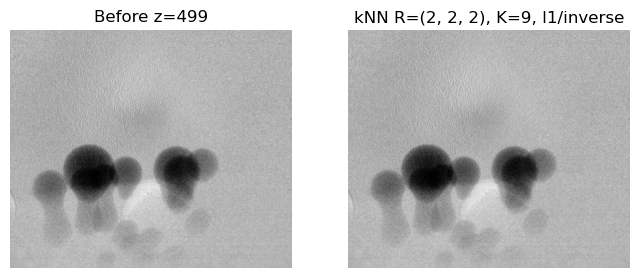

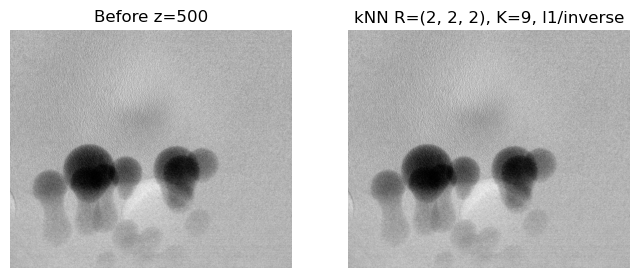

Preview → /home/askiran/data/Normalized_log/_knn3d_preview


In [3]:
files = list_files_gray(KNN_DATA_DIR)
idxs  = choose_middle_indices(len(files), KNN_K_PREVIEW)
volK  = np.stack([to_float01(read_slice_gray(files[k]))[0] for k in idxs], 0).astype(np.float32)

denK = knn3d_intensity_cupy_chunked_tiled(
    volK,
    radius=KNN_R, K=KNN_K,
    metric=KNN_METRIC, weighting=KNN_WEIGHTING,
    w_sigma=KNN_W_SIGMA, w_eps=KNN_W_EPS,
    chunk=KNN_CHUNK, tile=KNN_TILE
)
qm = quality_metrics_3d(volK, denK); print("kNN preview metrics:", qm)

# show two slices
for ii in [len(idxs)//2, min(len(idxs)//2+1, len(idxs)-1)]:
    show_pair(volK[ii], denK[ii], f"Before z={idxs[ii]}",
              f"kNN R={KNN_R}, K={KNN_K}, {KNN_METRIC}/{KNN_WEIGHTING}")

# save preview
for i,z in enumerate(idxs):
    s = read_slice_gray(files[z])
    out_u = from_float01(denK[i], {"dtype": s.dtype, "scale": 255.0 if s.dtype==np.uint8 else 65535.0})
    iio.imwrite(os.path.join(OUT_KNN_PREV, f"slice_{z:04d}_knn.tif"), out_u)
print("Preview →", OUT_KNN_PREV)


# Cell 11.3 - k-NN: slabbed full data

In [ ]:
files = list_files_gray(KNN_DATA_DIR)
Z = len(files)
ovl_z = int(KNN_R[0])  # Z-overlap equals rz

for z0 in range(0, Z, KNN_SLAB):
    z1 = min(z0 + KNN_SLAB, Z)
    zs = max(0, z0 - ovl_z); ze = min(Z, z1 + ovl_z)

    slab = np.stack([to_float01(read_slice_gray(p))[0] for p in files[zs:ze]], 0).astype(np.float32)
    den_ext = knn3d_intensity_cupy_chunked_tiled(
        slab,
        radius=KNN_R, K=KNN_K,
        metric=KNN_METRIC, weighting=KNN_WEIGHTING,
        w_sigma=KNN_W_SIGMA, w_eps=KNN_W_EPS,
        chunk=KNN_CHUNK, tile=KNN_TILE
    )
    core = den_ext[(z0 - zs):(z1 - zs)]

    for i, z in enumerate(range(z0, z1)):
        s = read_slice_gray(files[z])
        out_u = from_float01(core[i], {"dtype": s.dtype, "scale": 255.0 if s.dtype==np.uint8 else 65535.0})
        iio.imwrite(os.path.join(OUT_KNN_FULL, f"slice_{z:04d}.tif"), out_u)

print("Full kNN →", OUT_KNN_FULL)


# Cell 12 - Midrange Filtering (local (min+max)/2)

# Cell 12.1 - Prereqs: 3D Midrange

In [4]:
# ===== 3D MIDRANGE — PREREQS =====
MIDR_DATA_DIR  = "/home/askiran/data/Normalized_log"
MIDR_K_PREVIEW = 10
MIDR_WIN = (3,5,5)     # odd window; set kz=1 for 2D per-slice
MIDR_SLAB = 128
OUT_MIDR_PREV = f"{MIDR_DATA_DIR.rstrip('/')}/_midr3d_preview"
OUT_MIDR_FULL = f"{MIDR_DATA_DIR.rstrip('/')}/_midr3d_full"
os.makedirs(OUT_MIDR_PREV, exist_ok=True); os.makedirs(OUT_MIDR_FULL, exist_ok=True)

def _odd3(s):
    s = (s,s,s) if isinstance(s,int) else tuple(s)
    return tuple(int(v)|1 for v in s)

def midrange3d_cupy(vol_f01, win=(3,5,5)):
    win = _odd3(win)
    x = cp.asarray(vol_f01, dtype=cp.float32)
    mn = cnd.minimum_filter(x, size=win, mode='reflect')
    mx = cnd.maximum_filter(x, size=win, mode='reflect')
    y = (mn + mx) * 0.5
    return cp.asnumpy(cp.clip(y, 0.0, 1.0))


# Cell 12.2 - Midrange: preview on ~10 slices

Midrange preview metrics: {'score': 0.9632708709521053, 'noise_reduction': 1.5509812431575447, 'edge_retention': 0.0817053126439463, 'var_before': 0.0036418591625988483, 'var_after': 0.0023481000680476427}


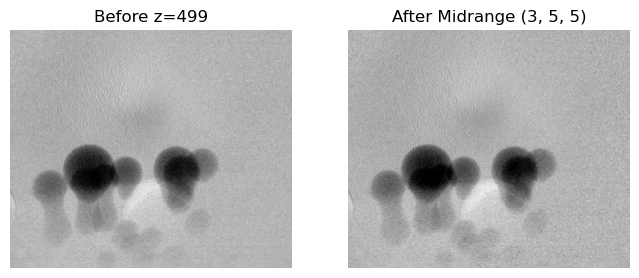

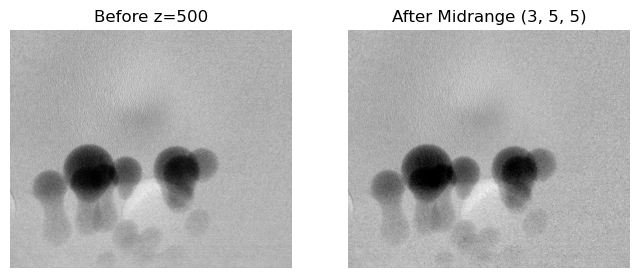

Preview → /home/askiran/data/Normalized_log/_midr3d_preview


In [5]:
files = list_files_gray(MIDR_DATA_DIR)
idxs = choose_middle_indices(len(files), MIDR_K_PREVIEW)
volK = np.stack([to_float01(read_slice_gray(files[k]))[0] for k in idxs], 0).astype(np.float32)

denK = midrange3d_cupy(volK, win=MIDR_WIN)
qm = quality_metrics_3d(volK, denK); print("Midrange preview metrics:", qm)

for ii in [len(idxs)//2, min(len(idxs)//2+1, len(idxs)-1)]:
    show_pair(volK[ii], denK[ii], f"Before z={idxs[ii]}", f"After Midrange {MIDR_WIN}")

for i,z in enumerate(idxs):
    s = read_slice_gray(files[z])
    out_u = from_float01(denK[i], {"dtype": s.dtype, "scale": 255.0 if s.dtype==np.uint8 else 65535.0})
    iio.imwrite(os.path.join(OUT_MIDR_PREV, f"slice_{z:04d}_midr.tif"), out_u)
print("Preview →", OUT_MIDR_PREV)


# Cell 12.3 - Midrange: slabbed full data

In [ ]:
files = list_files_gray(KNN_DATA_DIR)
Z = len(files)
ovl_z = int(KNN_R[0])     # Z-overlap (0 if rz=0)

for z0 in range(0, Z, KNN_SLAB):
    z1 = min(z0 + KNN_SLAB, Z)
    zs = max(0, z0 - ovl_z); ze = min(Z, z1 + ovl_z)

    slab = np.stack([to_float01(read_slice_gray(p))[0] for p in files[zs:ze]], 0).astype(np.float32)
    den_ext = knn3d_intensity_cupy_chunked_tiled(
        slab, radius=KNN_R, K=KNN_K, chunk=KNN_CHUNK, tile=KNN_TILE
    )
    core = den_ext[(z0 - zs):(z1 - zs)]

    for i, z in enumerate(range(z0, z1)):
        s = read_slice_gray(files[z])
        out_u = from_float01(core[i], {"dtype": s.dtype, "scale": 255.0 if s.dtype==np.uint8 else 65535.0})
        iio.imwrite(os.path.join(OUT_KNN_FULL, f"slice_{z:04d}.tif"), out_u)

print("Full kNN →", OUT_KNN_FULL)

# Cell 13 Contrast-Dependent Outlier Removal (CDOR)

**Goal**: suppress impulsive / speckle outliers while preserving edges by **raising the outlier threshold in high-contrast regions**.

## Model
For each voxel \(x\), compute over a local window:
- **Robust center**: local median \(m\)
- **Robust scale**: \( \sigma_R = 1.4826 \cdot \text{MAD} = 1.4826 \cdot \text{median}(|x - m|) \)
  (or use local STD if you choose the faster option)
- **Local contrast** \(C\): either **range** \(=\max-\min\), **std**, or smoothed **gradient**

Define a **contrast-dependent threshold**:
\[
T = k_\sigma \,\sigma_R \;+\; \alpha \, C
\]
Then **clip** deviations toward the median:
\[
y = m + \text{clip}(x - m,\; -T,\; T) \quad\text{(soft-clipping)}
\]
Soft clipping avoids flattening details; optional **hard replace** sets \(y=m\) when \(|x-m|>T\).

## Parameters
- `WIN=(wz,wy,wx)` — odd window; set `wz=1` for 2D per-slice
- `SIGMA_MODE`: `"mad"` (robust) or `"std"` (faster)
- `CONTRAST`: `"range"` (fast, default), `"std"`, or `"grad"`
- `K_SIGMA (kσ)`: baseline threshold multiplier on robust scale (e.g., 2.5–4.0)
- `ALPHA (α)`: contrast weight (e.g., 0.2–0.8)
- `REPLACE`: `"soft"` (clip to band) or `"median"` (hard replace)

## Overlaps for streaming
- Z-overlap: `ovl_z = floor(wz/2)`
- Tile Y/X overlaps: `ovl_y = floor(wy/2)`, `ovl_x = floor(wx/2)`
(also sufficient for gradient because its kernel is small)

## Good starting points
- **General microscopy (3D)**: `WIN=(3,5,5)`, `kσ=3.0`, `α=0.4`, `SIGMA_MODE="mad"`, `CONTRAST="range"`, `REPLACE="soft"`
- **Fast pass / large stacks**: `WIN=(1,5,5)`, `kσ=3.0`, `α=0.5`, `SIGMA_MODE="std"`

Evaluate with your `quality_metrics_3d` (noise reduction in flats vs edge retention) and visual inspection on 2–3 slices.


# Cell 13.1 - Prereqs (choose input path; defines GPU function)

In [6]:
# ===== Contrast-Dependent Outlier Removal (CDOR) — PREREQS =====

# ---- Dataset & outputs (change path as needed) ----
CDOR_DATA_DIR   = "/home/askiran/data/Normalized_log"
CDOR_K_PREVIEW  = 10
OUT_CDOR_PREV   = f"{CDOR_DATA_DIR.rstrip('/')}/_cdor_preview"
OUT_CDOR_FULL   = f"{CDOR_DATA_DIR.rstrip('/')}/_cdor_full"
os.makedirs(OUT_CDOR_PREV, exist_ok=True); os.makedirs(OUT_CDOR_FULL, exist_ok=True)

# ---- CDOR parameters ----
CDOR_WIN        = (3,5,5)       # (wz,wy,wx) odd; wz=1 => 2D per-slice
CDOR_SIGMA_MODE = "mad"         # "mad" (robust) or "std" (faster)
CDOR_CONTRAST   = "std"       # "range" | "std" | "grad"
CDOR_K_SIGMA    = 3.0           # baseline threshold multiplier
CDOR_ALPHA      = 0.4           # contrast weight
CDOR_REPLACE    = "soft"        # "soft" | "median"

# ---- Streaming controls ----
CDOR_TILE       = (768,768)     # YX core tile size
CDOR_SLAB       = 96            # Z core slices per pass

# ========== Helpers ==========
def _odd3(s):
    s = (s,s,s) if isinstance(s,int) else tuple(s)
    return tuple(int(v)|1 for v in s)

def _local_stats(x, win, sigma_mode="mad", contrast="range", eps=1e-6):
    """
    x: cp.float32 (Zp,Yp,Xp) in [0,1]
    Returns: median m, robust_scale sr, contrast C
    """
    win = _odd3(win)
    # robust center
    m = cnd.median_filter(x, size=win, mode='reflect')
    # robust or fast scale
    if sigma_mode == "mad":
        mad = cnd.median_filter(cp.abs(x - m), size=win, mode='reflect')
        sr  = cp.float32(1.4826) * mad  # robust sigma
    else:  # "std"
        mu  = cnd.uniform_filter(x, size=win, mode='reflect')
        mu2 = cnd.uniform_filter(x*x, size=win, mode='reflect')
        var = cp.maximum(mu2 - mu*mu, 0.0)
        sr  = cp.sqrt(var + eps)

    # local contrast
    if contrast == "std":
        C = sr
    elif contrast == "grad":
        # smoothed gradient magnitude (reduce noise on C)
        gx = cnd.sobel(x, axis=2); gy = cnd.sobel(x, axis=1); gz = cnd.sobel(x, axis=0)
        g  = cp.sqrt(gx*gx + gy*gy + gz*gz)
        C  = cnd.uniform_filter(g, size=_odd3((1,3,3)), mode='reflect')
    else:  # "range"
        mn = cnd.minimum_filter(x, size=win, mode='reflect')
        mx = cnd.maximum_filter(x, size=win, mode='reflect')
        C  = mx - mn

    return m, sr, C

def cdor3d_cupy(vol_f01, win=(3,5,5), k_sigma=3.0, alpha=0.4,
                sigma_mode="mad", contrast="range", replace="soft", eps=1e-6):
    """
    Contrast-dependent outlier removal on GPU (CuPy).
    vol_f01: np.float32 (Z,Y,X) in [0,1]
    replace: "soft" (clip to ±T) or "median" (hard replace to m)
    """
    x = cp.asarray(vol_f01, dtype=cp.float32)
    m, sr, C = _local_stats(x, win, sigma_mode=sigma_mode, contrast=contrast, eps=eps)
    T = cp.float32(k_sigma) * sr + cp.float32(alpha) * C

    if replace == "median":
        y = cp.where(cp.abs(x - m) > T, m, x)
    else:  # soft clip
        delta = x - m
        y = m + cp.clip(delta, -T, T)

    return cp.asnumpy(cp.clip(y, 0.0, 1.0))

def cdor3d_tiled(vol_f01, win=(3,5,5), k_sigma=3.0, alpha=0.4,
                 sigma_mode="mad", contrast="range", replace="soft",
                 tile=(768,768)):
    """
    YX tiling with (win//2) overlap; returns np.float32 in [0,1].
    """
    wz,wy,wx = _odd3(win)
    oy, ox = (wy//2, wx//2)
    Ty, Tx = map(int, tile)
    x = cp.asarray(vol_f01, dtype=cp.float32)
    Z, Y, X = x.shape
    out = cp.empty_like(x)

    for y0 in range(0, Y, Ty):
        y1 = min(y0 + Ty, Y)
        ys = max(0, y0 - oy); ye = min(Y, y1 + oy)
        for x0 in range(0, X, Tx):
            x1 = min(x0 + Tx, X)
            xs = max(0, x0 - ox); xe = min(X, x1 + ox)

            patch = x[:, ys:ye, xs:xe]
            filt  = cdor3d_cupy(cp.asnumpy(patch), win=win, k_sigma=k_sigma, alpha=alpha,
                                sigma_mode=sigma_mode, contrast=contrast, replace=replace)
            # back to GPU only to stitch (keeps API consistent)
            filt = cp.asarray(filt, dtype=cp.float32)
            out[:, y0:y1, x0:x1] = filt[:, (y0-ys):(y1-ys), (x0-xs):(x1-xs)]
            del patch, filt
    return cp.asnumpy(out)


# Cell 13.2 Contrast-Dependent Outlier Removal (CDOR): preview on ~10 slices

CDOR preview metrics: {'score': 0.9969345734654638, 'noise_reduction': 1.0033493802956883, 'edge_retention': 0.9873123632201268, 'var_before': 0.0036418591625988483, 'var_after': 0.0036297019105404615}


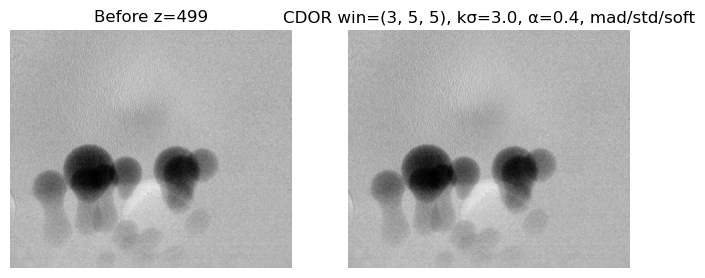

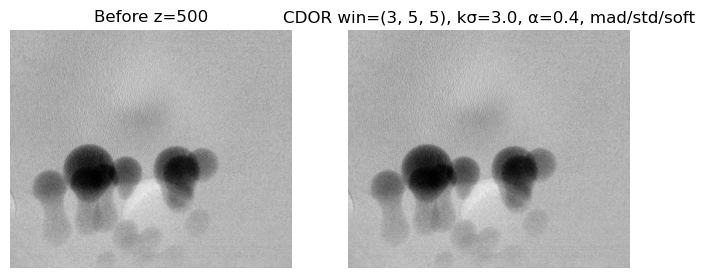

Preview → /home/askiran/data/Normalized_log/_cdor_preview


In [7]:
files = list_files_gray(CDOR_DATA_DIR)
idxs  = choose_middle_indices(len(files), CDOR_K_PREVIEW)
volK  = np.stack([to_float01(read_slice_gray(files[k]))[0] for k in idxs], 0).astype(np.float32)

denK = cdor3d_tiled(
    volK,
    win=CDOR_WIN, k_sigma=CDOR_K_SIGMA, alpha=CDOR_ALPHA,
    sigma_mode=CDOR_SIGMA_MODE, contrast=CDOR_CONTRAST, replace=CDOR_REPLACE,
    tile=CDOR_TILE
)

qm = quality_metrics_3d(volK, denK); print("CDOR preview metrics:", qm)

# show two representative slices
for ii in [len(idxs)//2, min(len(idxs)//2+1, len(idxs)-1)]:
    show_pair(volK[ii], denK[ii], f"Before z={idxs[ii]}",
              f"CDOR win={CDOR_WIN}, kσ={CDOR_K_SIGMA}, α={CDOR_ALPHA}, {CDOR_SIGMA_MODE}/{CDOR_CONTRAST}/{CDOR_REPLACE}")

# save preview slices
for i,z in enumerate(idxs):
    s = read_slice_gray(files[z])
    out_u = from_float01(denK[i], {"dtype": s.dtype, "scale": 255.0 if s.dtype==np.uint8 else 65535.0})
    iio.imwrite(os.path.join(OUT_CDOR_PREV, f"slice_{z:04d}_cdor.tif"), out_u)

print("Preview →", OUT_CDOR_PREV)


# Cell 13.3 Contrast-Dependent Outlier Removal (CDOR): full data

In [ ]:
files = list_files_gray(CDOR_DATA_DIR)
Z = len(files)

# Z-overlap = half window
ovl_z = CDOR_WIN[0]//2

for z0 in range(0, Z, CDOR_SLAB):
    z1 = min(z0 + CDOR_SLAB, Z)
    zs = max(0, z0 - ovl_z); ze = min(Z, z1 + ovl_z)

    slab = np.stack([to_float01(read_slice_gray(p))[0] for p in files[zs:ze]], 0).astype(np.float32)

    den_ext = cdor3d_tiled(
        slab,
        win=CDOR_WIN, k_sigma=CDOR_K_SIGMA, alpha=CDOR_ALPHA,
        sigma_mode=CDOR_SIGMA_MODE, contrast=CDOR_CONTRAST, replace=CDOR_REPLACE,
        tile=CDOR_TILE
    )
    core = den_ext[(z0 - zs):(z1 - zs)]

    for i, z in enumerate(range(z0, z1)):
        s = read_slice_gray(files[z])
        out_u = from_float01(core[i], {"dtype": s.dtype, "scale": 255.0 if s.dtype==np.uint8 else 65535.0})
        iio.imwrite(os.path.join(OUT_CDOR_FULL, f"slice_{z:04d}.tif"), out_u)

print("Full CDOR →", OUT_CDOR_FULL)


# 3D Image Filtering — Quick Reference (Definitions, Preview Metrics, SLABs)

## Notation & Conventions
- **Volume shape:** `Z × Y × X` (slices × height × width), grayscale.
- **Normalization:** Processing runs on `float32` in **[0,1]**. I/O preserves original dtype (`uint8`, `uint16`, or float).
- **Anisotropy:** If voxel spacing is non-isotropic (e.g., Δz > Δx,Δy), prefer **smaller Z radii** or use voxel spacing in diffusion.

---

## Core Parameters (by method)

### Median (3D)
- **Kernel size** `size = (kz, ky, kx)` — each must be odd (e.g., `(3,5,5)`).
- **2D mode:** set `kz = 1` → `(1, ky, kx)` applies per-slice median.

### Non-Local Means (3D)
- **Patch radius** `patch_radius = (rz, ry, rx)` → patch size is `(2r+1)` in each dim.
- **Search radius** `search_radius = (sz, sy, sx)` → search window `(2s+1)` in each dim (dominates runtime).
- **Strength** `h`: smoothing strength; typically set as `h = H_FACTOR · σ`, where `σ` is noise std (estimated).
- **Variance compensation:** if `sigma` is passed, SSD is adjusted by `2·σ²·patch_size` to reduce bias.
- **2D mode:** set `rz = sz = 0` → `(0, ry, rx)` and `(0, sy, sx)`.

### Anisotropic Diffusion (Perona–Malik, 3D)
- **Iterations** `ITERS` (more → smoother).
- **Conductance** `k` (smaller → stronger edge preservation).
- **Time step** `λ` (keep `λ ≤ 0.25` for 6-neighbor scheme).
- **Spacing** `vox = (dz, dy, dx)` — scales gradients for anisotropic voxels.
- **2D mode:** set `vox = (1e9, 1, 1)` to effectively disable Z coupling (or drop Z neighbors in code).

### Unsharp Mask (3D)
- **Gaussian sigma** `σ_usm = (σz, σy, σx)` for the blur (smaller → crisper; larger → coarser).
- **Amount** `A` (0.5–1.2 typical).
- **Threshold** `T` in [0,1] to avoid boosting small noise (e.g., `0.01`).
- **2D mode:** set `σz = 0.0`.

---

## Noise Estimation (used by NLM)
**Laplacian MAD estimator (robust):**
\[
\sigma \approx \frac{\mathrm{median}\big(|\nabla^2 V - \mathrm{median}(\nabla^2 V)|\big)}{0.6745}
\]
where \( V \) is the (preview) volume, \(\nabla^2\) is the Laplacian. Use this σ to set `h = H_FACTOR·σ` (start with `H_FACTOR ∈ [0.6, 1.0]`).

---

## Preview Metrics (reference-free)
Computed on a preview block (K middle slices), all in float [0,1].

1) **3D gradient magnitudes** (Sobel):
\[
g_b = \|\nabla \text{before}\|,\quad g_a = \|\nabla \text{after}\|
\]

2) **Regions**
- **Edges:** top \( q \) quantile of \( g_b \) (default \( q=0.85 \), i.e., strongest 15%).
- **Flats:** \( g_b \le \) median(\( g_b \)).

3) **Noise reduction (flat regions)**
\[
\text{var}_b = \mathrm{Var}(\text{before}|\text{flat}), \quad
\text{var}_a = \mathrm{Var}(\text{after}|\text{flat})
\]
\[
\text{noise\_reduction} = \frac{\text{var}_b}{\max(\text{var}_a,\varepsilon)}
\]
Interpretation: **>1** means noise decreased (e.g., 3.0 ≈ 3× reduction).

4) **Edge retention (edge regions)**
\[
GE_b = \mathbb{E}[g_b^2|\text{edge}], \quad GE_a = \mathbb{E}[g_a^2|\text{edge}]
\]
\[
\text{edge\_retention} = \frac{GE_a}{\max(GE_b,\varepsilon)}
\]
Interpretation: **≈1.0** preserves edges; <1 blurs; >1 sharpens/boosts.

5) **Composite score**
\[
\text{score} = \alpha \cdot \text{noise\_reduction} + \beta \cdot \text{edge\_retention}
\]
Defaults: \( \alpha=0.6, \beta=0.4 \) (bias toward denoising).  
**Targets:** edge_retention \( \approx 0.95\text{–}1.05 \), noise_reduction \( \gtrsim 2 \) (data-dependent).

---

## SLAB Streaming (memory-safe full-volume processing)

**Goal:** Process a big `Z×Y×X` stack in chunks to fit RAM/VRAM, while keeping correct neighborhoods.

Per iteration:
1. Pick a **core** Z-range `[z0:z1)` of length **SLAB** (the slices you will output this pass).
2. Compute **overlap in Z** (context) based on the method:
   - **Median:** \( \text{ovl}_z = \lfloor k_z/2 \rfloor \)
   - **NLM:** \( \text{ovl}_z = r_z + s_z \) (patch_z + search_z)
   - **USM (Gaussian):** \( \text{ovl}_z = \lceil 3 \cdot \sigma_z \rceil \)
   - **Aniso. Diffusion:** \( \text{ovl}_z \approx \min(16,\max(2,\text{ITERS})) \) (conservative)
3. Read the **extended slab** `[zs:ze)` where  
   \( zs = \max(0, z0 - \text{ovl}_z),\ \ ze = \min(Z, z1 + \text{ovl}_z) \).
4. Run the filter on the extended slab **on GPU**.
5. **Crop** the result back to the **core** `[z0:z1)` and write those slices.
6. Advance `z0←z1` and repeat until all slices are processed.

**Tuning SLAB:**
- Larger **SLAB** → fewer I/O/launches (faster) but more memory.
- Smaller **SLAB** → safer on memory, slightly slower.
- In **2D mode** (e.g., NLM with `rz=sz=0`, median `kz=1`, USM `σz=0`), **ovl_z=0**, so you can choose a larger SLAB comfortably.

---

## Practical Starting Points

- **Median (fine) **: `size = (3,3,3)`; **(2D)** `(1,3,3)`
- **Median (more speckle)**: `size = (3,5,5)` or `(5,5,5)` (watch for flattening thin structures)

- **NLM (fine detail)**: `patch=(1,2,2)`, `search=(2,6,6)`, `h = 0.6–0.8·σ`
- **NLM (heavier denoise)**: keep patch; `search=(2,8,8)`; `h = 0.9–1.2·σ`

- **Diffusion**: `ITERS=10`, `k=0.05`, `λ=0.15`, `vox=(dz,dy,dx)`; **2D** via `vox=(1e9,1,1)`

- **USM (light)**: `σ=(0.7,1.2,1.2)`, `amount=0.8`, `threshold=0.01`; **2D** via `σz=0.0`

---

## Reading Results
- Always compare **before/after** with the **same display range** (e.g., 1–99% percentiles of the original) to avoid visual bias.
- Outputs are saved as `.tif` per slice, preserving original **shape** and **bit-depth**.



# Spatial Filters (GPU) — Quick Reference

**Conventions:** volume `(Z,Y,X)`, grayscale float32 in `[0,1]`.  
**SLAB streaming:** process `SLAB` core slices with Z-overlap, crop, and advance.

| Filter | Main params | What it does | Typical Z-overlap |
|---|---|---|---|
| Wiener (local) | `WIN=(kz,ky,kx)`, `sigma_n` | Local MMSE with local mean/var | `⌊kz/2⌋` |
| Bilateral (3D) | `R=(rz,ry,rx)`, `sigma_s`, `sigma_r` | Edge-preserving, range-aware | `rz` |
| Gaussian (3D) | `SIG=(σz,σy,σx)` | Linear smoothing | `⌈3·σz⌉` |
| Guided (3D) | `R=(rz,ry,rx)`, `eps`, (guide=`I`) | Edge-preserving, linear model | `rz` |
| k-NN (local, intensity) | `R`, `K` | Average of K closest intensities in window | `rz` |
| Midrange | `WIN` | `(min+max)/2` in window | `⌊kz/2⌋` |

**Tuning tips:**  
- Start small in Z (e.g., `kz=1..3` or `rz=1`) if voxels are anisotropic.  
- For **Bilateral**, balance `sigma_s` (spatial) vs `sigma_r` (intensity): smaller `sigma_r` preserves edges more.  
- For **Guided**, `eps` controls edge sensitivity (smaller = stronger edge preservation).  
- For **k-NN**, keep `R` modest (e.g., `(1,2,2)`) and `K` ~ 5–15 to avoid VRAM spikes.  
- All outputs preserve **shape** and **bit-depth** via `from_float01`.


# For 2D operation, set kz=0 (Bilateral/kNN) or kz=1 (Wiener/Midrange windows) or σz=0 (Gaussian), or r_z=0 (Guided).